## Importação de biblioteca

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import os 
from scipy.stats import shapiro, probplot

import seaborn as sns 
import matplotlib.pyplot as plt


## Carregamento de dados

In [2]:
path = Path(r'../data/raw/desafio_nps_fase_1.csv')
url = 'https://github.com/AnaRaquelCafe/POSTECH_AI_SCIENTIST/blob/main/Base%20de%20dados%20Tech%20Challenge/desafio_nps_fase_1.csv'

In [3]:
df = pd.read_csv(path)

### Variaveis

In [4]:
#barplot
nps_map = {1: 'Detratores', 2: 'Passivo', 3: 'Promotores'}


cores_nps = {
    "Detratores": "#E74C3C", # Vermelho
    "Passivo": "#F1C40F",    # Amarelo
    "Promotores": "#27AE60"  # Verde
}

dicionario_colunas = {
    'complaints_count' :'numero de reclamações',
    'delivery_delay_days':'dias de atraso',
    'customer_service_contacts':'numero de contatos com atendimento',
    'resolution_time_days':'dias para resolução',
    'nps_score':'NPS'
    
}

### Funções 

In [5]:
#Categorias 

def nps_class(df):
    if df['nps_score'] <= 6:
        return 'detractors'
    elif df['nps_score'] < 9:
        return 'passives'
    else:
        return 'promoter'

In [6]:
#Graficos

def gerar_barplot(df,x):
    
    plt.figure(figsize=(6,4))
    
    sns.countplot(data=df.assign(nps_labels=df['nps_cat'].map(nps_map)), 
                  x=x, 
                  hue='nps_labels',
                  palette=cores_nps
                 )
    
    
    plt.title(f'Distribuição de Categorias NPS por {dicionario_colunas[x]}')
    plt.show()



def gerar_kdeplot(df,x):
    plt.figure(figsize=(10, 6))

    df_plot = df.assign(nps_labels=df['nps_cat'].map(nps_map))
    
    sns.kdeplot(
        data=df_plot,
        x=x,
        hue='nps_labels',
        palette=cores_nps,
        fill=True,      
        bw_adjust=2,
        common_norm=False, 

    )
    
    plt.title(f'Tendência de Categorias NPS por {dicionario_colunas[x]}')
    plt.xlabel(dicionario_colunas[x])
    plt.ylabel('Densidade de Clientes')
    plt.show()



def gerar_hisplot(df,x):
    plt.figure(figsize=(10, 6))

    df_plot = df.assign(nps_labels=df['nps_cat'].map(nps_map))
    
    sns.histplot(
        data=df_plot,
        x=x,
        hue='nps_labels',
        palette=cores_nps,
        multiple="stack",  # Empilha as categorias
        discrete=True,     # números inteiros
        shrink=0.8         # pedding
    )
    
    plt.title(f'Tendência de Categorias NPS por {dicionario_colunas[x]}')
    plt.xlabel(dicionario_colunas[x])
    plt.ylabel('Densidade de Clientes')
    plt.show()


def grafico_linhas_percentual(df,coluna):
    df_trend = pd.crosstab(df[coluna], df['nps_cat'], normalize='index') * 100
    
    df_trend.columns = nps_map.values() # ['Detratores', 'Passivo', 'Promotores']
    
    df_trend.plot(kind='line', marker='o', color=cores_nps, figsize=(10, 6))
    
    plt.title(f'Percentual de Categorias NPS conforme {dicionario_colunas[coluna]}')
    plt.ylabel('% de Clientes')
    plt.xlabel(f'{dicionario_colunas[coluna]}')
    plt.grid(alpha=0.3)
    plt.show()


def analyze_distribution_and_ci(data, confidence=0.95, n_bootstrap=5000):
    data = np.array(data)
    n = len(data)
    mean = np.mean(data)

    # Teste Shapiro-Wilk para normalidade
    shapiro_stat, shapiro_p = shapiro(data)

    # Plot histograma
    plt.figure(figsize=(6, 2))

    plt.subplot(1, 2, 1)
    plt.hist(data, bins=10)
    plt.title("Histograma")

    # QQ-Plot
    plt.subplot(1, 2, 2)
    probplot(data, dist="norm", plot=plt)
    plt.title("QQ-Plot")

    plt.show()

    # Bootstrap CI
    alpha = 1 - confidence
    boot_means = []
    for _ in range(n_bootstrap):
        sample = np.random.choice(data, size=n, replace=True)
        boot_means.append(np.mean(sample))

    lower = np.percentile(boot_means, (alpha/2) * 100)
    upper = np.percentile(boot_means, (1 - alpha/2) * 100)
    ci_bootstrap = (lower, upper)

    print(f"Média da amostra: {mean:.3f}")
    print(f"IC Bootstrap ({confidence*100:.0f}%): {ci_bootstrap[0]:.3f}  a  {ci_bootstrap[1]:.3f}")
    print(f"p-valor Shapiro-Wilk: {shapiro_p:.4f} {'(normal)' if shapiro_p>0.05 else '(não normal)'}")


### Qualidade dos Dados

In [7]:
df.shape

(2500, 19)

In [8]:
df['customer_tenure_months'].unique()

array([ 14,   1, 111, 117,  50,  75,  68,  37,  60,  70,  28,  81,  85,
        42, 113, 114,  21,  86,  74, 105, 119,  20,  79,  26, 101,  39,
        71,  57,  41,  16, 106,  23,   3,   5,  73,  15,  33,  67,  19,
        49,  69,  95, 109, 108, 116,   9,  83,  64,  53, 100,  45,  82,
        80,  25,  24,  38,  88,  30,  72,  51,  47, 112,   6,  94,  36,
         7, 103, 102, 107,  34,  27,  29,  90,  62,  92,  56,  18,  99,
        22,  54,  48,  43,  40,  11,  76,  32, 104,  35,  96,  66,  93,
        59,  13,  31,   2,  78,  87, 115,  65,  44,  97,  84,  10,  77,
         8,  61, 118,  17,  46,  52,  98,  63, 110,  55,  12,   4,  58,
        89,  91], dtype=int64)

In [9]:
df.dtypes

customer_id                    int64
customer_age                   int64
customer_region               object
customer_tenure_months         int64
order_id                       int64
order_value                  float64
items_quantity                 int64
discount_value               float64
payment_installments           int64
delivery_time_days             int64
delivery_delay_days            int64
freight_value                float64
delivery_attempts              int64
customer_service_contacts      int64
resolution_time_days           int64
nps_score                    float64
repeat_purchase_30d            int64
complaints_count               int64
csat_internal_score          float64
dtype: object

In [10]:
df.isnull().sum().sum()

0

### Classificação de NPS

Começaremos arredondando os valores de NPS, para não trabalharmos com numeros com pontos fluantes

Classificaremos os NPS  

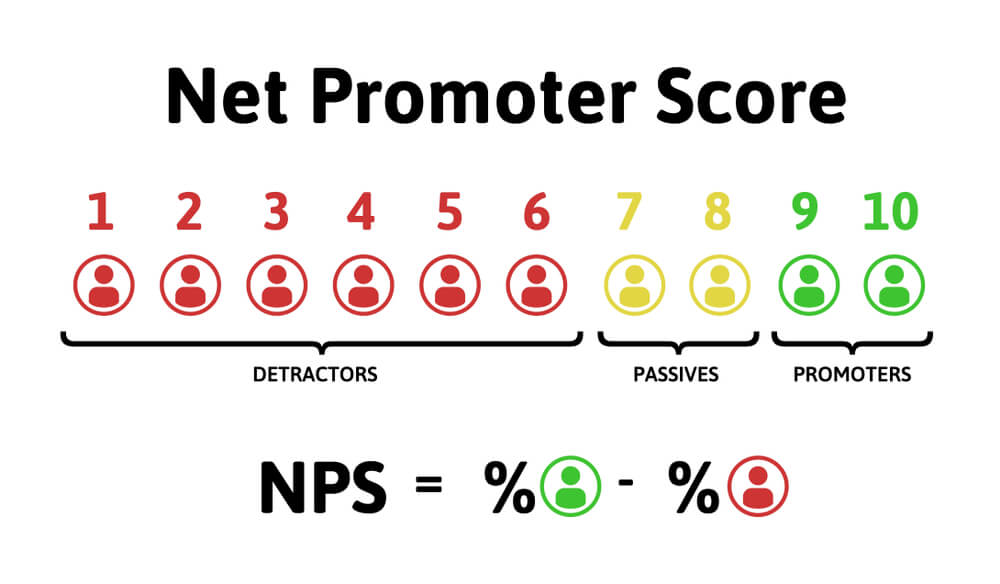

In [11]:
df['classificacao_nps'] = df.apply(nps_class,axis=1)
df['classificacao_nps'].value_counts().to_frame().assign(pct=df['classificacao_nps'].value_counts(1)*100)

,count,pct
classificacao_nps,,
detractors,1851,74.04
passives,539,21.56
promoter,110,4.40


Nossa base demonstra 74% dos clientes como detratores, apenas 4% como promotores. 

In [12]:
#removendo da base colunas que nao serão necessárias
df_nps = df.drop(columns={'customer_id','csat_internal_score','classificacao_nps'})

**Categorizando as regiões com o one-hot encoder**

In [13]:
df_nps['customer_region'].unique()

array(['Nordeste', 'Sul', 'Centro-Oeste', 'Norte', 'Sudeste'],
      dtype=object)

In [14]:
region_cat = df_nps[['customer_region']]

try:
    from sklearn.preprocessing import OrdinalEncoder # apenas para gerar um ImportError se Scikit-Learn < 0.20
    from sklearn.preprocessing import OneHotEncoder
except ImportError:
    from future_encoders import OneHotEncoder # Scikit-Learn < 0.20

cat_encoder = OneHotEncoder()
region_cat_1hot = cat_encoder.fit_transform(region_cat)
region_cat_1hot

<2500x5 sparse matrix of type '<class 'numpy.float64'>'
	with 2500 stored elements in Compressed Sparse Row format>

Vamos transformar as colunas categiruas em numericas para conseguirmos fazer analises posteriores


In [15]:
# Transformando a coluna em categoria e extraindo o código numérico
df_nps['customer_region_encoded'] = df_nps['customer_region'].astype('category').cat.codes

region_mapping = dict(enumerate(df_nps['customer_region'].astype('category').cat.categories))
df_nps.drop(columns=['customer_region'], axis=1, inplace=True)
print(f"Mapeamento: {region_mapping}")

Mapeamento: {0: 'Centro-Oeste', 1: 'Nordeste', 2: 'Norte', 3: 'Sudeste', 4: 'Sul'}


In [16]:
df_nps['nps_score'] = np.round(df_nps["nps_score"])

In [17]:
df_nps.head(2)

,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,customer_region_encoded
0,63,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,7.0,0,3,1
1,20,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.0,0,3,4


---

## Explorando o problema

**Pergunta principal**
> quais fatores operacionais realmente influenciam a satisfação do cliente ? <br>
como a empresa pode agir de forma proativa para melhorar a experiência antes mesmo da
aplicação da pesquisa de NPS?

### 1.Entendimento do negócio:

**Qual problema de negócio está sendo resolvido?** <br>
>Precisamos antecipar o resultado do NPS antes da pesquisa acontecer.

**Por que o NPS é importante para um e-commerce?**
> um NPS é importante por se tratar de uma métrica de satisfação dos clientes, a partir disso podemos avaliar a experiencia de nossos clientes tendo assim uma referencia da qualidade de nossos serviços, uma experiencia positiva pode afetar diretamente a receita através da recompra e fidelização dos clientes, custos por evitar retrabalho de logistica e/ou atendimentos especificos. uma alta NPS também é um sinal da reputação de nossa empresa o que ajuda a atrair novos clientes 

**Quais áreas poderiam se beneficiar desses insights?**

*podemos receber diversos benefios ao criar uma cultura voltada ao NPS* <br>
>- **Logistico:** analisar os atrasos e pensar em estratégias para diminuir o tempo de entrega <br>
>- **Atendimento ao cliente:** um numero de NPS maior indica menos contatos de resolução de problemas, acarretando indiretamente em menor tempo de resolução de problemas.  <br>
> - **Marketing:** ao identificarmos clientes promotores poderiamos por exemplo, criar programas de indicação de clientes com benefios, a experiencia positiva dos promotores pode ser uma alavanca importante para a divulgação dos nossos serviços. <br> 

### 1.1 impactos do NPS <br>

**Recompra** <br>
> recompra está diretamente relacionada aos promotores
> Churn está diretamente relacionado aos detratadores
<br>

**Boca a boca** <br>
> promotores podem gerar divulgação de nossos serviços de forma organica
> detratores podem gerar uma reputação negativa de nosso serviços impedindo de alcançarmos novos clientes
<br>


**Market share em e-commerce**<br>
> quanto melhor a experiencia de nossos clientes maior será o nosso market share, principalmente por se tratar de um e-commerce, esse setor especifico está a um clique de distancia de uma troca de fornecedores. 

**Quais indicadores de mercado poderiam complementar essa análise? Exemplos: benchmarks de NPS, SLA logístico, concorrência.**

### 2. Definição da Target:


**Qual variável representa a satisfação do cliente?** <br>
> nps_score
<br>

**Por que ela foi escolhida?** <br>
> é uma métrica recuperada de pesquisas, uma informação vinda dos próprios clientes é o indicador final de satisfação.
<br>

**Em que momento da jornada essa informação é coletada?** <br>
> ao fim da jornada de compras, no pós atendimento
<br>

**Existe algum risco de usar essa variável de forma inadequada?** <br>
> não temos a resposta de todos os clientes, normalmente teremos os maiores detratores ou promotores, além de não conseguir trazer toda a experiencia de nossos clientes é uma variavel simplificada

# 3. Análise Exploratória dos Dados (EDA)


● Que tipo de cliente tende a ter NPS mais alto ou mais baixo? <br>

#### **Quais fatores parecem mais críticos para a satisfação?**

faremos uma analise utilizando corr para identificar uma associação linear direta entre as notas de nps como um todo

In [18]:
correlacoes = df_nps.corr()['nps_score'].sort_values(ascending=True)
correlacoes

delivery_delay_days         -0.595482
complaints_count            -0.492177
customer_service_contacts   -0.348971
resolution_time_days        -0.190509
freight_value               -0.042073
customer_tenure_months      -0.013194
customer_age                -0.008848
delivery_time_days           0.002107
order_id                     0.012457
items_quantity               0.014429
customer_region_encoded      0.027598
payment_installments         0.028124
delivery_attempts            0.028631
discount_value               0.029046
order_value                  0.035779
repeat_purchase_30d          0.562242
nps_score                    1.000000
Name: nps_score, dtype: float64

In [19]:
print('variaveis com maior probabilidade de afetar a satisfação')
correlacoes[abs(correlacoes) > 0.15]

variaveis com maior probabilidade de afetar a satisfação


delivery_delay_days         -0.595482
complaints_count            -0.492177
customer_service_contacts   -0.348971
resolution_time_days        -0.190509
repeat_purchase_30d          0.562242
nps_score                    1.000000
Name: nps_score, dtype: float64

#### **O que mais gera detratores? <br>**

para responder essa pergunta primeiro vamos categorizar as nps <br>
> 1 detratores
 2 passivos
 3 promotores

In [20]:
df_nps["nps_cat"] = pd.cut(df_nps["nps_score"],
                               bins=[-1,6 , 8, 10],
                               labels=[1, 2, 3])

In [21]:
print('nova associação, mas agora quanto relação das categoria do NPS')
nps_cat = df_nps.corr()['nps_cat'].sort_values(ascending=True)
nps_cat[:4]

nova associação, mas agora quanto relação das categoria do NPS


complaints_count            -0.409154
delivery_delay_days         -0.385278
customer_service_contacts   -0.235164
resolution_time_days        -0.150430
Name: nps_cat, dtype: float64

agora faremos uma analise utilizando as médias por grupos.<br>

In [22]:
#dataframe agrupado por categoria 
comparativo = df_nps.groupby('nps_cat',observed=False).mean()

o objetivo dessa analise é entender as maiores correlações entre os detratores  <br>
para isso iremos agrupar e faremos uma média de todos os dados, após isso iremos filtrar apenas os detratores [1]

In [23]:
perfil_detrator = comparativo.loc[1] / comparativo.median() 
perfil_detrator = perfil_detrator.sort_values(ascending=False)

print(perfil_detrator[:4])

delivery_delay_days          2.068525
complaints_count             1.584318
customer_service_contacts    1.558074
resolution_time_days         1.214548
dtype: float64


apenas para fim de estudos veremos as relações entre os promotores também

In [24]:
perfil_promotor = comparativo.loc[3] / comparativo.median() 
perfil_promotor = perfil_promotor.sort_values(ascending=False)

print(perfil_promotor[:4])

repeat_purchase_30d       5.014286
nps_score                 1.274223
items_quantity            1.053754
customer_tenure_months    1.035436
dtype: float64


#### <font size="5"> **Estudo de ruptura em contato do cliente** </font>

##### <font size="5">**Ruptura em numero de reclamações**</font>

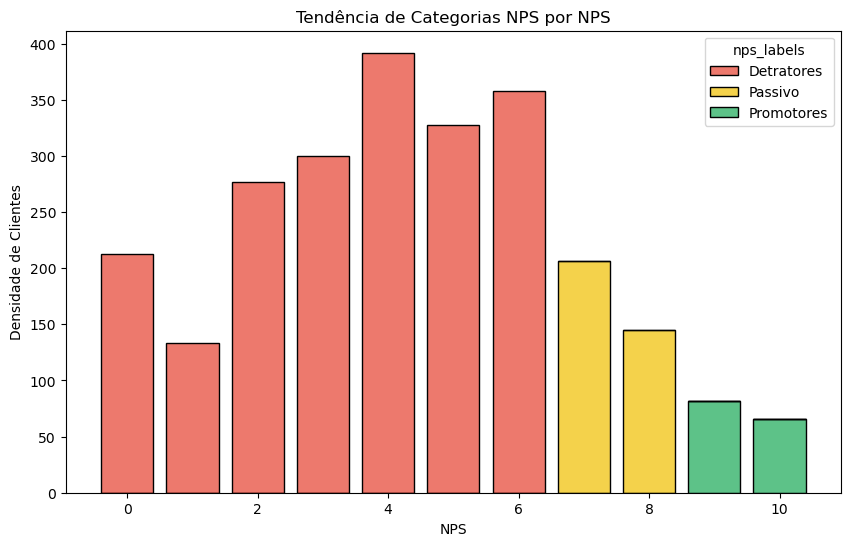

In [25]:
gerar_hisplot(df_nps,'nps_score')

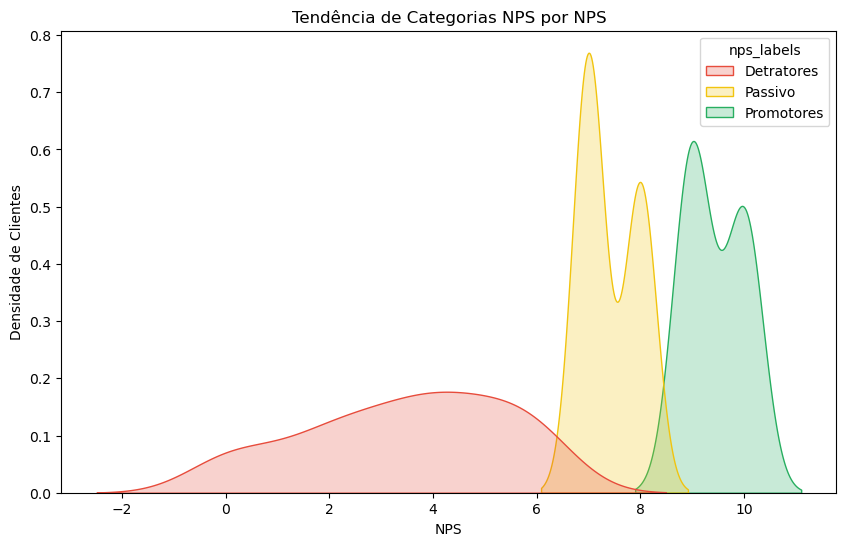

In [26]:
gerar_kdeplot(df_nps,'nps_score')

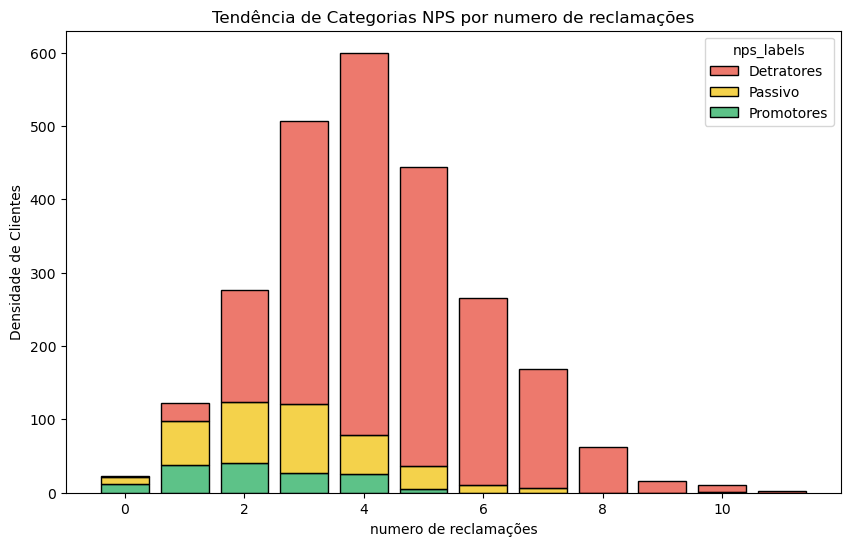

In [27]:
#histplot
gerar_hisplot(df_nps,'complaints_count')

> ao analisar a quantidade de reclamações é possivel notar uma tendencia de maior numero de detratores a partir da terceira reclamação 

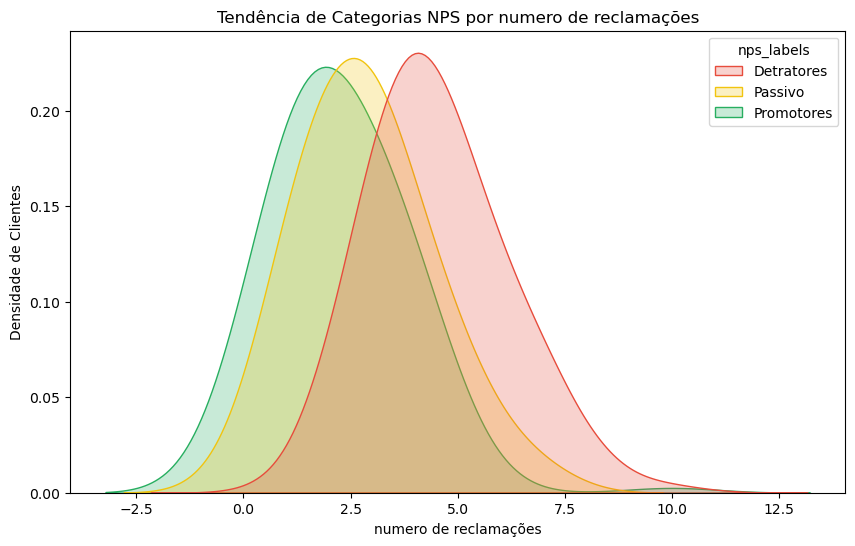

In [28]:
gerar_kdeplot(df_nps,'complaints_count')

> novamente identificamos um ponto de transição a partir de três reclamações,
aqui é onde o numero de detratores supera o numero de promotores e o ponto de ruptura aparenta ser a quarta reclamação,
onde o numero de promotores passa a ser substancialmente menor que o numero de detratores
vamos fazer agora uma analise percentual de nps por numero de reclamações

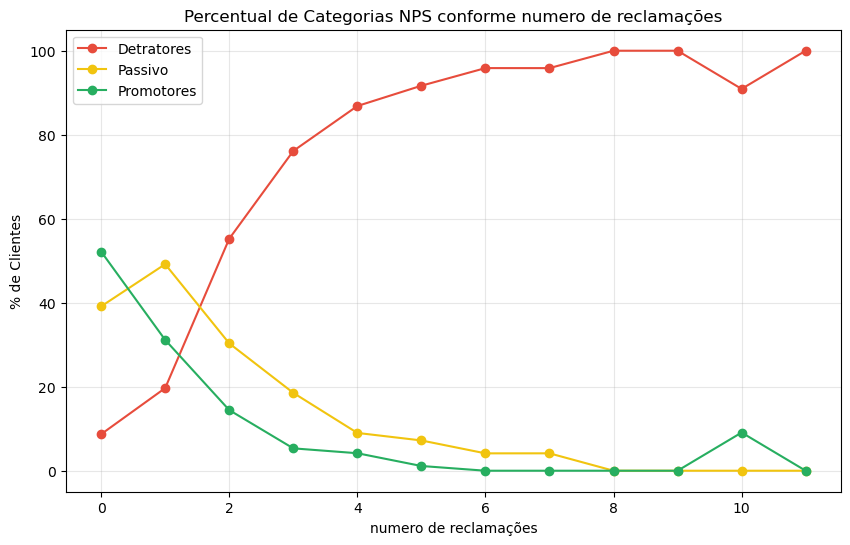

In [29]:
grafico_linhas_percentual(df_nps,'complaints_count')

> Em termos percentuais o numero de detratores supera os promotores a partir da segunda reclamação. 

##### <font size="5">**Ruptura em dias de atraso**</font>

faremos uma analise de contagem geral das categorias em relação ao dia de atrasos

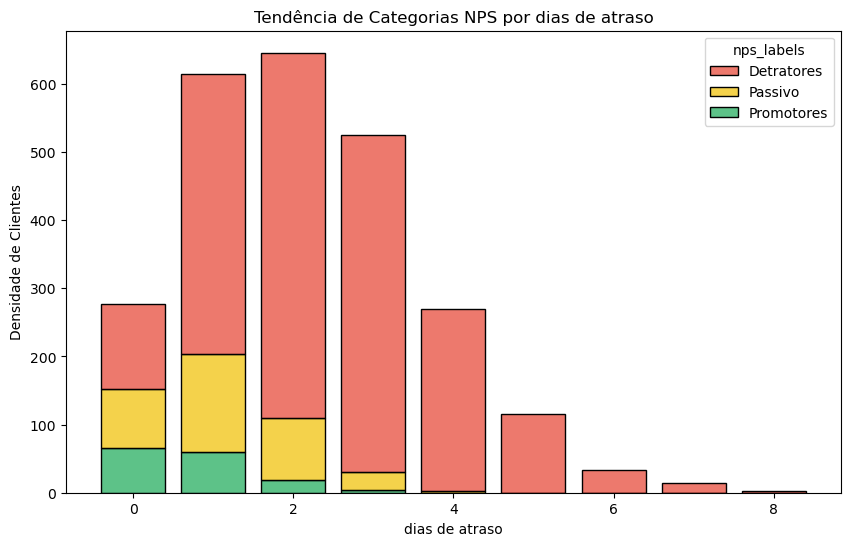

In [30]:
gerar_hisplot(df_nps,'delivery_delay_days')

podemos notar que a partir de 1 dia de atraso já temos um aumento substancial de detratores, e a partir do segundo dia de atraso o numero de promotores é quase nulo. 
agora vamos fazer uma analise de densidade 

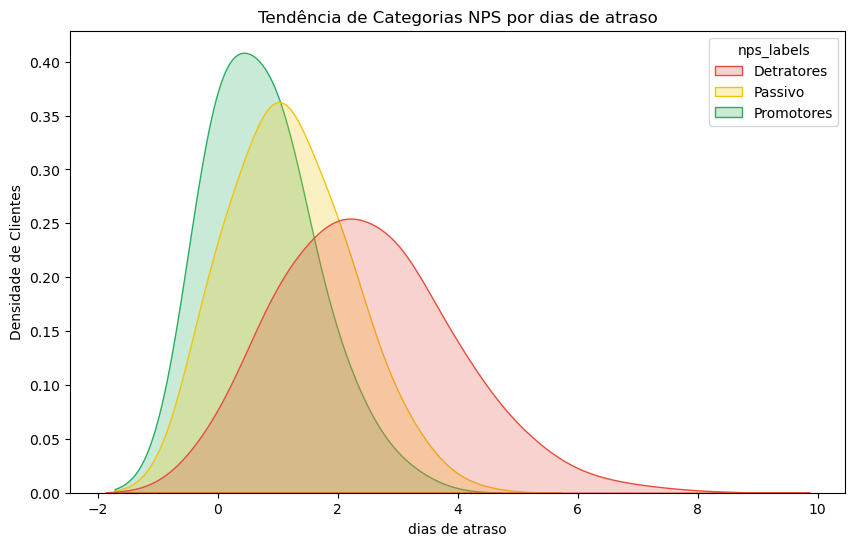

In [31]:
gerar_kdeplot(df_nps,'delivery_delay_days')

novamente identificamos um ponto de transição no segundo dia, aqui é onde o numero de detratores supera o numero de promotores e o ponto de ruptura aparenta ser o terceiro dia, onde o numero de promotores passa a ser bem baixo
vamos fazer agora uma analise percentual de nps por dia de atraso

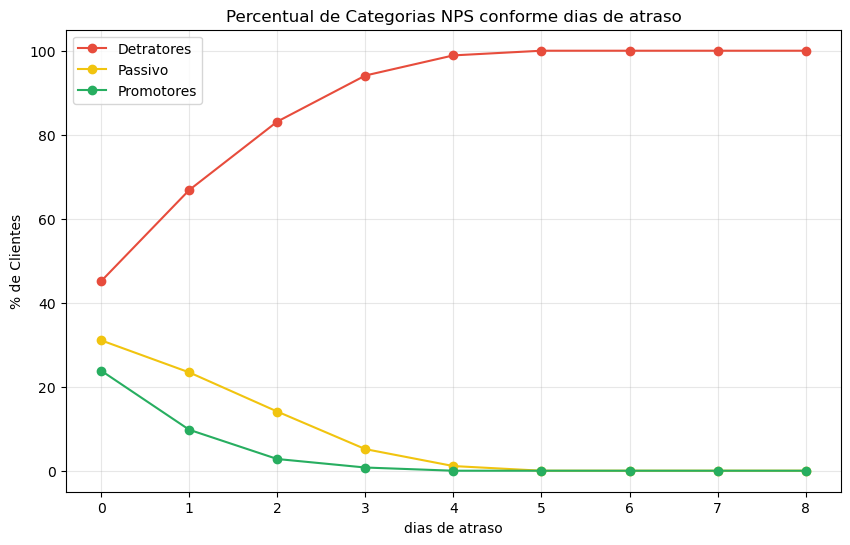

In [32]:
grafico_linhas_percentual(df_nps,'delivery_delay_days')

##### <font size="5">**Ruptura em numero de contatos**</font>

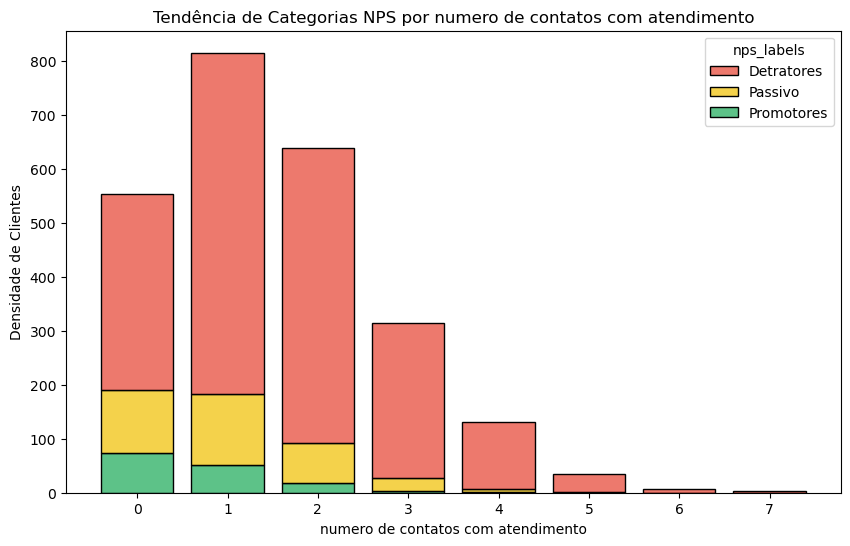

In [33]:
gerar_hisplot(df_nps,'customer_service_contacts')

Existe uma tendencia a detratores já no primeiro contato com nossa equipe de atendimento

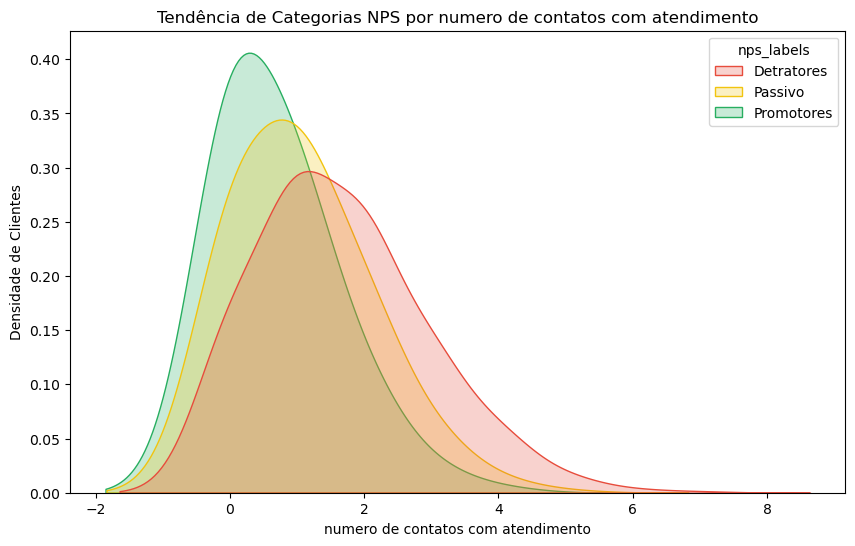

In [34]:
gerar_kdeplot(df_nps,'customer_service_contacts')

Podemos notar uma tendencia a promotores que entram em contato apenas uma vez com o SAC

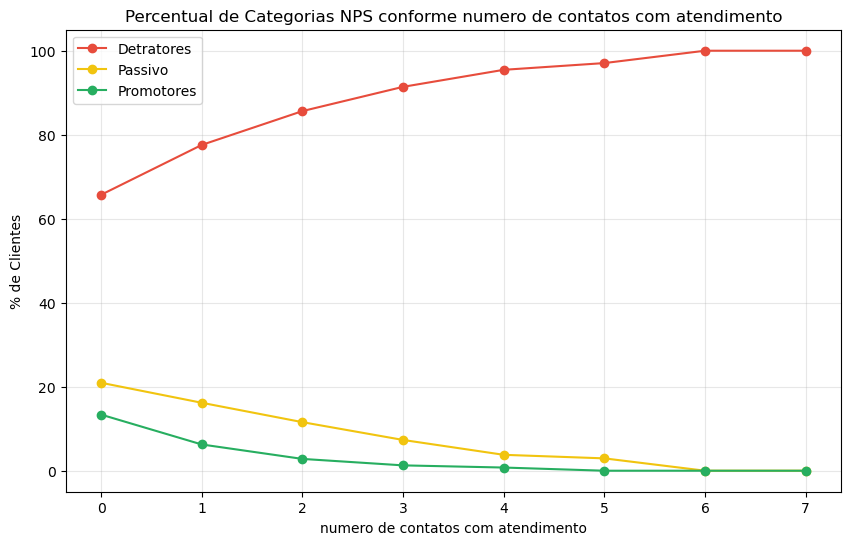

In [35]:
grafico_linhas_percentual(df_nps,'customer_service_contacts')

existe uma forte tendencia a detratores até mesmo antes de entrar em contato com atendimento. E conseguimos manter um percentual de passivos e promotores em torno de 40% se conseguirmos resolver o problema antes do segundo contato.

Vamos avaliar agora a ultima variavel com forte correlação

##### <font size="5">**Ruptura em em dias para a resolução de problemas**</font>

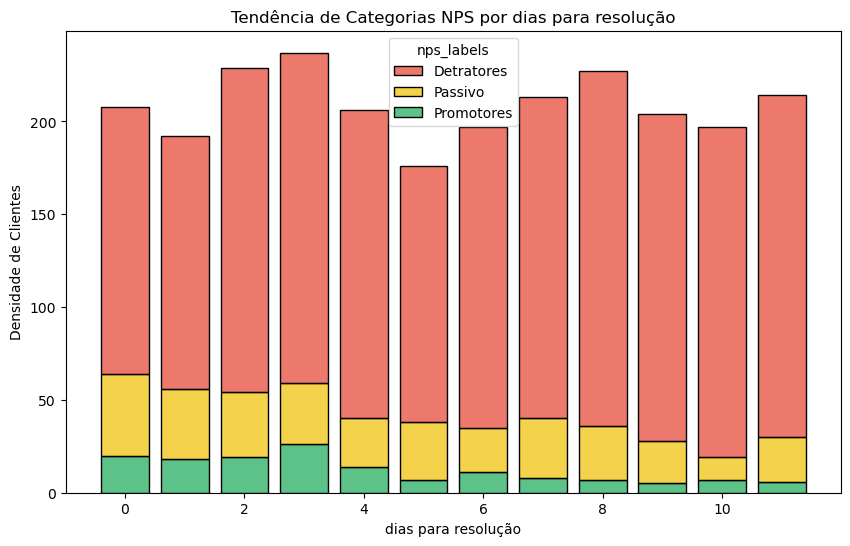

In [36]:
gerar_hisplot(df_nps,'resolution_time_days')

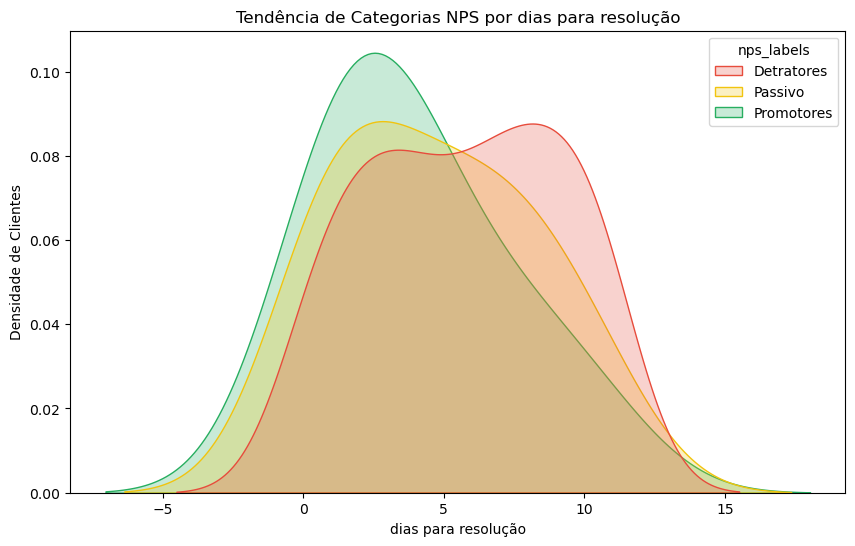

In [37]:
gerar_kdeplot(df_nps,'resolution_time_days')

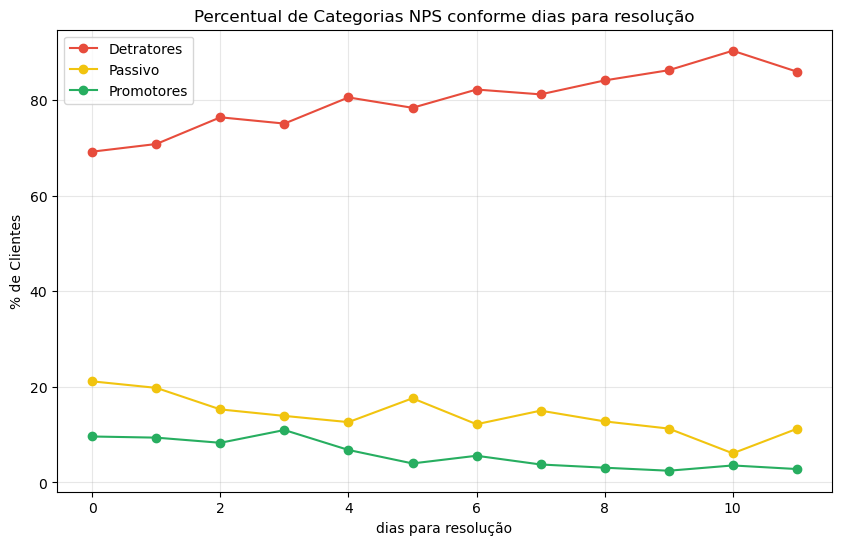

In [38]:
grafico_linhas_percentual(df_nps,'resolution_time_days')

Existe uma maior tendencia a se tornar detrator a partir de um atraso de 4 antes da resolução do problema   

#### <font size="6"> **Conclusão sobre os pontos de ruptura:** </font> <br>
**é possivel chegar a algumas hipóteses:** <br>
> a partir da terceira reclamação os clientes tem maior chance de se tornarem detratores<br>
> a partir do segundo dia de atraso os clientes tem maior probabilidade de se tornarem detratores <br>
> a partir do segundo contato existe maior probabilidade dos clientes se tornarem detratores <br>
> a partir do terceiro dia sem a resolução de problemas, existe uma maior probabilidade do cliente se tornar detrator <br>

#### <font size="5"> **Estudo de hipoteses** </font>

In [39]:
from scipy.stats import mannwhitneyu

def teste_mann_w_u(grupo_1, grupo_2,h0="",alpha=0.05 ):
    stat, p_value = mannwhitneyu(grupo_1, grupo_2, alternative='two-sided')

    
    print(f"Estatística U: {stat}")
    print(f"p-valor: {p_value}")
    
    if p_value < alpha:
        print('Resultado: Há diferença simgnificativa.')
        print(f"Rejeitamos a hipótese nula (H0): {h0}")
        
    else:
        print('Resultado: Não há diferença significativa.')
        print(f"Não rejeitamos a hipótese nula (H0). {h0} ")

##### <font size="5">h1 = a partir da terceira reclamação os clientes tem maior chance de se tornarem detratores</font>

In [40]:
hipotese_nula_reclamacoes = 'NPS se mantem igual com menos de três reclamações'
reclamacoes_h0 = df_nps[df_nps['complaints_count'] < 3]['nps_score']
reclamacoes_h1= df_nps[df_nps['complaints_count'] >= 3]['nps_score']

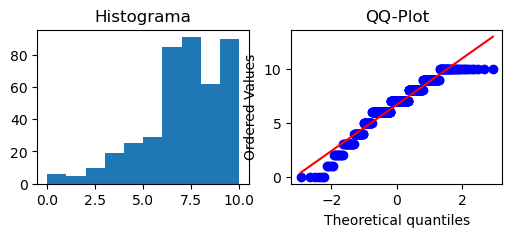

Média da amostra: 6.682
IC Bootstrap (95%): 6.472  a  6.884
p-valor Shapiro-Wilk: 0.0000 (não normal)


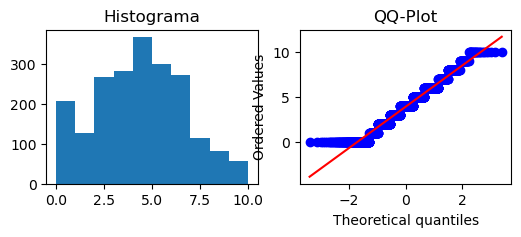

Média da amostra: 3.909
IC Bootstrap (95%): 3.808  a  4.010
p-valor Shapiro-Wilk: 0.0000 (não normal)


In [41]:
analyze_distribution_and_ci(reclamacoes_h0)
analyze_distribution_and_ci(reclamacoes_h1)

In [42]:
teste_mann_w_u(reclamacoes_h0,reclamacoes_h1,hipotese_nula_reclamacoes)

Estatística U: 709385.5
p-valor: 1.4885974322785602e-90
Resultado: Há diferença simgnificativa.
Rejeitamos a hipótese nula (H0): NPS se mantem igual com menos de três reclamações


##### <font size="5">h1 = a partir do 2º dia de atraso os clientes tem maior probabilidade de se tornarem detratores </font>

In [43]:
hipotese_nula_atraso = 'NPS se mantem igual com até dois dias de atraso'
atraso_h0 = df_nps[df_nps['delivery_delay_days'] < 3]['nps_score']
atraso_h1= df_nps[df_nps['delivery_delay_days'] >= 3]['nps_score']

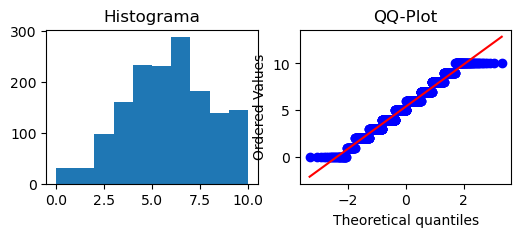

Média da amostra: 5.382
IC Bootstrap (95%): 5.270  a  5.491
p-valor Shapiro-Wilk: 0.0000 (não normal)


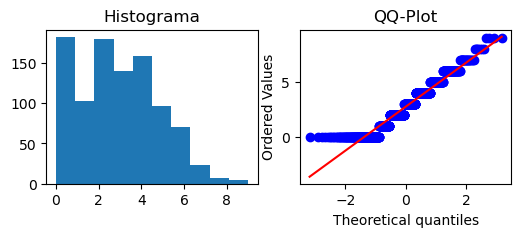

Média da amostra: 2.771
IC Bootstrap (95%): 2.639  a  2.901
p-valor Shapiro-Wilk: 0.0000 (não normal)


In [44]:
analyze_distribution_and_ci(atraso_h0)
analyze_distribution_and_ci(atraso_h1)

In [45]:
teste_mann_w_u(atraso_h0,atraso_h1,hipotese_nula_atraso)

Estatística U: 1178914.5
p-valor: 6.535731421716053e-140
Resultado: Há diferença simgnificativa.
Rejeitamos a hipótese nula (H0): NPS se mantem igual com até dois dias de atraso


##### <font size="5">h1 = a partir do segundo contato existe maior probabilidade dos clientes se tornarem detratores</font>

In [46]:
hipotese_nula_contatos = 'Não há alteração no NPS com menos de dois contatos com o SAC'
contatos_h0 = df_nps[df_nps['customer_service_contacts'] < 2]['nps_score']
contatos_h1 = df_nps[df_nps['customer_service_contacts'] >= 2]['nps_score']

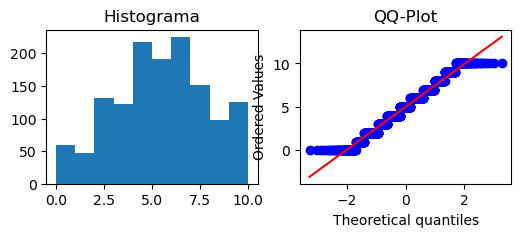

Média da amostra: 5.022
IC Bootstrap (95%): 4.889  a  5.148
p-valor Shapiro-Wilk: 0.0000 (não normal)


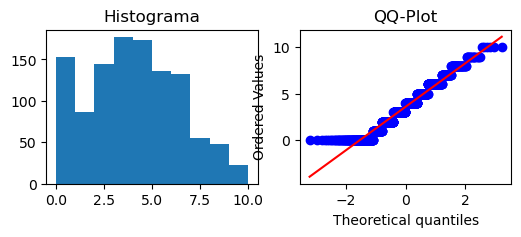

Média da amostra: 3.596
IC Bootstrap (95%): 3.455  a  3.734
p-valor Shapiro-Wilk: 0.0000 (não normal)


In [47]:
analyze_distribution_and_ci(contatos_h0)
analyze_distribution_and_ci(contatos_h1)

In [48]:
teste_mann_w_u(contatos_h0,contatos_h1,hipotese_nula_contatos)

Estatística U: 1020350.0
p-valor: 2.3153361337682074e-43
Resultado: Há diferença simgnificativa.
Rejeitamos a hipótese nula (H0): Não há alteração no NPS com menos de dois contatos com o SAC


##### <font size="5">h1 = a partir do terceiro dia sem a resolução de problemas, existe uma maior probabilidade do cliente se tornar detrator </font>

In [49]:
hipotese_nula_resolucao = 'Não há alteração no NPS com menos de dois resolucao de problemas'
resolucao_h0 = df_nps[df_nps['resolution_time_days'] < 3]['nps_score']
resolucao_h1 = df_nps[df_nps['resolution_time_days'] >= 3]['nps_score']

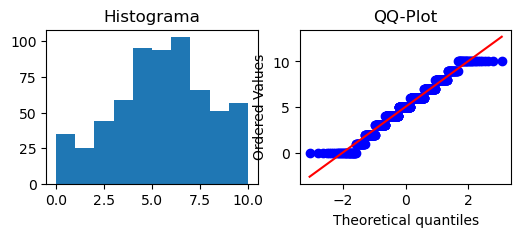

Média da amostra: 5.041
IC Bootstrap (95%): 4.847  a  5.240
p-valor Shapiro-Wilk: 0.0000 (não normal)


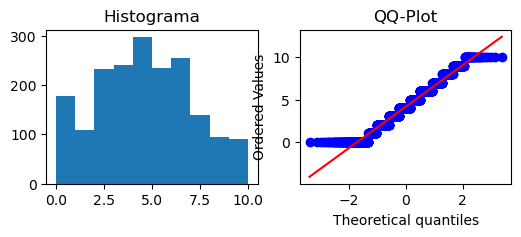

Média da amostra: 4.154
IC Bootstrap (95%): 4.040  a  4.269
p-valor Shapiro-Wilk: 0.0000 (não normal)


In [50]:
analyze_distribution_and_ci(resolucao_h0)
analyze_distribution_and_ci(resolucao_h1)

In [51]:
teste_mann_w_u(resolucao_h0,resolucao_h1,hipotese_nula_resolucao)

Estatística U: 706556.0
p-valor: 3.082849513398862e-14
Resultado: Há diferença simgnificativa.
Rejeitamos a hipótese nula (H0): Não há alteração no NPS com menos de dois resolucao de problemas


#### <font size="6"> **Conclusão das hipoteses:** </font> <br>
**Nossas hipoteses foram validadas** <br>

Para mentermos o NPS alto precisamos evitar mais de duas reclamações, não atrasar mais de um dia, resolver os problemas no primeiro contato dos clientes e em até dois dias após o contato

### Analise de perfil de cliente

primeiro vamos tentar criar um perfil com base nas hipoteses que levantamos, criando um score ponderado(Heuristica) 

In [52]:
# Definindo os pesos com base na sua correlação
df_nps['risk_score'] = (
    (df_nps['complaints_count'] >= 3).astype(int) * 2 +          # Forte corr (-0.44)
    (df_nps['delivery_delay_days'] >= 2).astype(int) * 2 +       # Forte corr (-0.41)
    (df_nps['customer_service_contacts'] >= 2).astype(int) * 1 + # Média corr (-0.24)
    (df_nps['resolution_time_days'] >= 3).astype(int) * 1        # Baixa corr (-0.15)
)

# -1 a 1: Baixo (No máximo 1 problema leve)
# 2 a 3: Médio (Problema grave ou combinação de leves)
# 4 a 5: Alto (Combo de problemas graves)
# 6 : Critico - Pontuação máxima


df_nps['risk_level'] = pd.cut(
    df_nps['risk_score'],
    bins=[-1, 1, 3, 5, 6], 
    labels=['Baixo', 'Médio', 'Alto', 'Crítico']
)

In [53]:
# relação 
print(df_nps.groupby('risk_level', observed=False)['order_value'].sum())

risk_level
Baixo      103676.83
Médio      238193.88
Alto       507889.71
Crítico    235888.93
Name: order_value, dtype: float64


In [54]:
# Verificando a média de NPS por nível de risco
print(df_nps.groupby('risk_level', observed=False)['nps_score'].mean())

risk_level
Baixo      7.562771
Médio      5.791897
Alto       3.982249
Crítico    2.467772
Name: nps_score, dtype: float64


In [55]:
#Filtrar apenas as colunas que podem trazer alguma analise para o perfil dos nossos clientes

df_perfil = df_nps[['customer_age',
                    'customer_tenure_months',
                    'order_value',
                    'items_quantity',
                    'discount_value',
                    'payment_installments',
                    'delivery_time_days',
                    'delivery_delay_days',
                    'freight_value',
                    'delivery_attempts',
                    'customer_service_contacts',
                    'resolution_time_days',
                    'repeat_purchase_30d',
                    'complaints_count',
                    'customer_region_encoded',
                    'risk_score',
                    'risk_level']
                ]

perfil = df_perfil.groupby('risk_level', observed=False).mean(numeric_only=True)

perfil.T

risk_level,Baixo,Médio,Alto,Crítico
customer_age,43.367965,43.769797,42.869822,44.180479
customer_tenure_months,60.229437,62.751381,60.630600,61.865562
order_value,448.817446,438.662762,429.323508,434.417919
items_quantity,3.320346,3.561694,3.477599,3.429098
discount_value,30.651775,32.294383,29.292781,27.797937
payment_installments,6.082251,6.103131,5.889265,6.121547
delivery_time_days,8.060606,7.804788,8.138631,7.968692
delivery_delay_days,0.510823,1.467772,2.479290,2.983425
freight_value,37.903030,37.950755,38.532857,37.928748
delivery_attempts,2.004329,2.012891,2.009298,1.990792


Faremos uma comparação de diferentes niveis de risco, utilizando o grupo de baixo risco como referencia (baseline= 1) <br>
Isso nos permitirá entender o quanto os problemas operacionais aumentam a medida que o risco do cliente cresce

In [56]:
perfil.columns

Index(['customer_age', 'customer_tenure_months', 'order_value',
       'items_quantity', 'discount_value', 'payment_installments',
       'delivery_time_days', 'delivery_delay_days', 'freight_value',
       'delivery_attempts', 'customer_service_contacts',
       'resolution_time_days', 'repeat_purchase_30d', 'complaints_count',
       'customer_region_encoded', 'risk_score'],
      dtype='object')

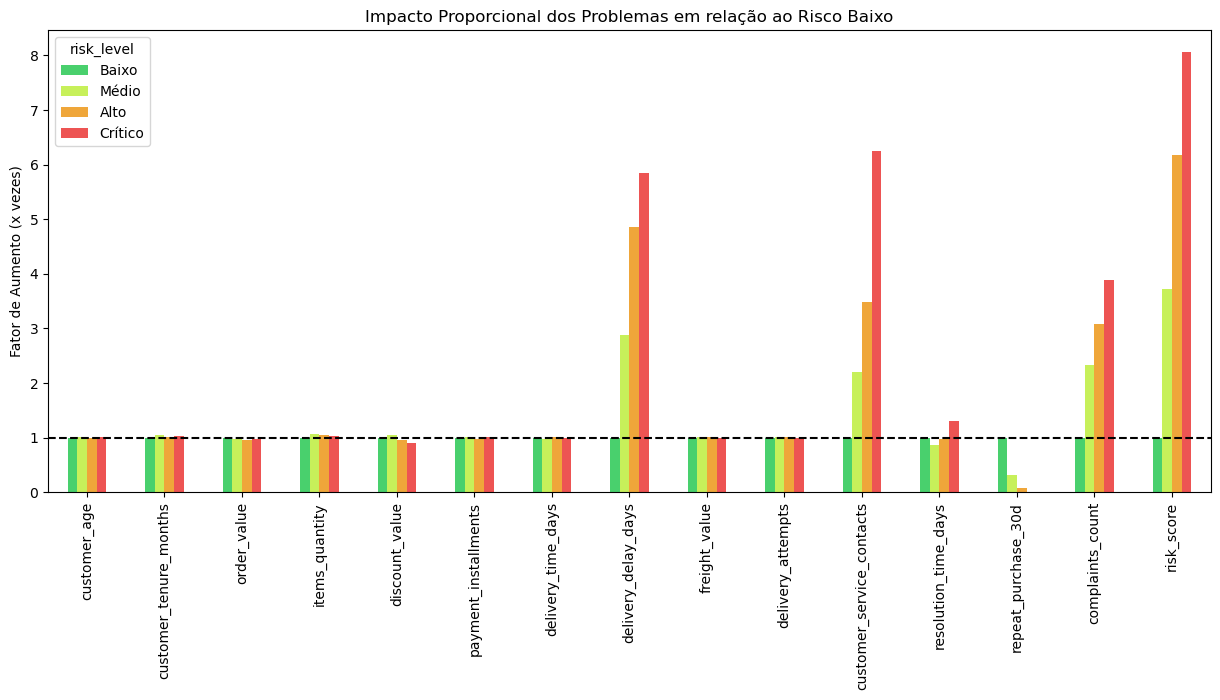

In [57]:
cores_temperatura = ['#49D06D', '#C7F05A', '#EFA63A', '#ED5453']
perfil_relativo = perfil / perfil.loc['Baixo']
perfil_relativo = perfil_relativo.drop(columns=['customer_region_encoded'])

ax = perfil_relativo.T.plot(kind='bar', figsize=(15, 6), color=cores_temperatura)
plt.axhline(y=1, color='black', linestyle='--', label='Base (Risco Baixo)')
plt.title('Impacto Proporcional dos Problemas em relação ao Risco Baixo')
plt.ylabel('Fator de Aumento (x vezes)')
plt.show()

Clientes de risco crítico em média, apresentam cerca de 11 vezes mais dias de atraso do que clientes de baixo risco. <br>
Clientes de risco crítico em média, apresentam cerca de 10 vezes mais contatos com o SAC do que clientes de baixo risco. <br>
Clientes de risco crítico em média, reclamam 7 vezes do que clientes de baixo risco.<br>


O tempo de entrega não é um problema, uma vez que sempre se mantem estável, entretanto o atraso na entrega demonstra um crescimento exponencial no perfil de risco de nossos clientes, um dos grandes problemas é a quebra de promessa de entrega e não o prazo médio de entrega. 

o mesmo também pode se notar ao avaliar o contato com o SAC, uma não resolução gera maior perfil de risco

#### Analise por regiao

Foi possivel identificar um pequeno destaque na região sudeste faremos uma breve analise por região para identificar se essa relação é forte

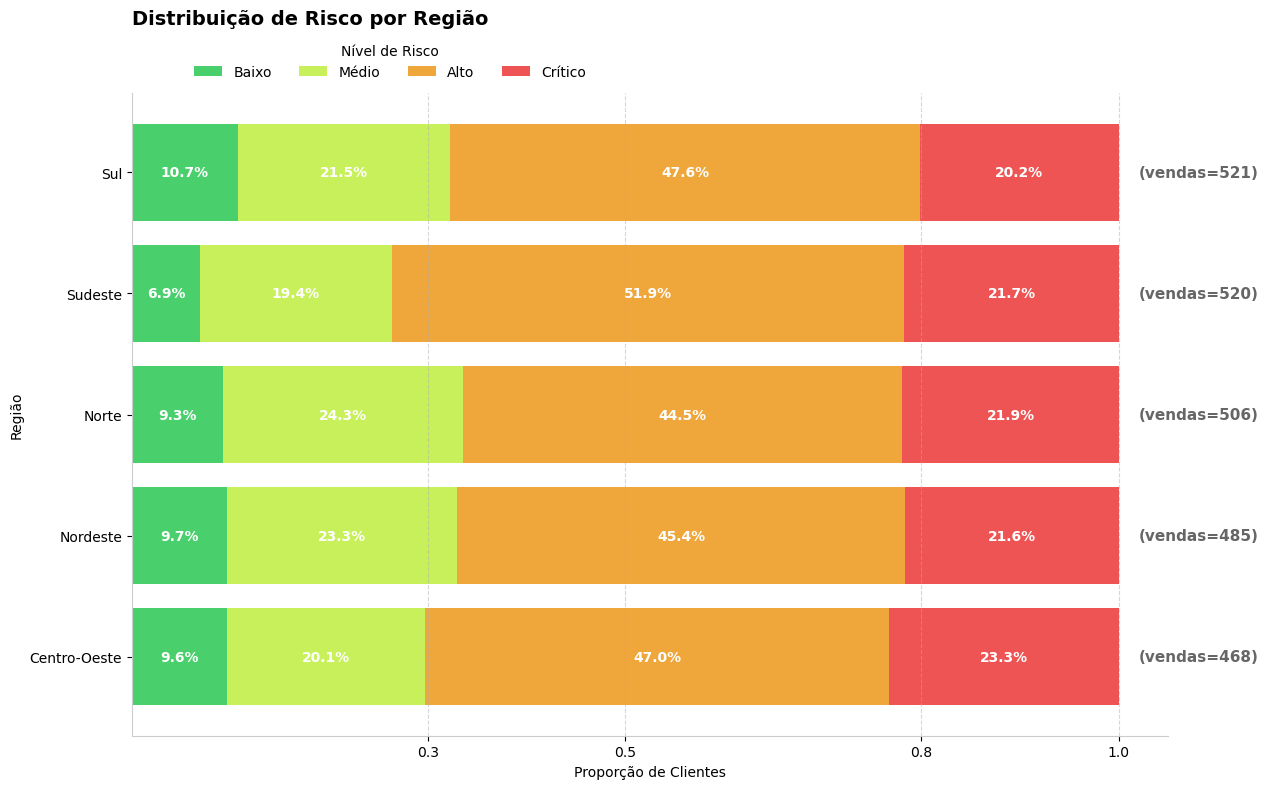

In [58]:
import pandas as pd
import matplotlib.pyplot as plt

regioes_nomeadas = df_nps['customer_region_encoded'].map(region_mapping)
distribuicao_risco = pd.crosstab(regioes_nomeadas, df_nps['risk_level'], normalize='index')

total_por_regiao = regioes_nomeadas.value_counts().reindex(distribuicao_risco.index)

ax = distribuicao_risco.plot(
    kind='barh', 
    stacked=True, 
    figsize=(15, 8), 
    color=cores_temperatura, 
    width=0.8
)

# --- ADICIONANDO O TOTAL À DIREITA ---
for i, (regiao, total) in enumerate(total_por_regiao.items()):
    ax.text(1.02, i, f'(vendas={total})', va='center', fontsize=11, color='#666666', fontweight='bold')

plt.title('Distribuição de Risco por Região', fontsize=14, fontweight='bold', loc='left', pad=50)
plt.xlabel('Proporção de Clientes')
plt.ylabel('Região')


plt.legend(title='Nível de Risco', loc='center right', fontsize=10,
           bbox_to_anchor=(0.45, 1.05), ncol=4, frameon=False)


for p in ax.patches:
    width = p.get_width()
    if width > 0.05: 
        ax.annotate(f'{width:.1%}', 
                    (p.get_x() + width/2, p.get_y() + p.get_height()/2),
                    ha='center', va='center', color='white', fontweight='bold')

ax.set_xticks([0.3, 0.5, 0.8, 1])
ax.grid(True, axis='x', linestyle='--', alpha=0.5)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

plt.tight_layout(rect=[0, 0, 0.85, 1])  
plt.show()

>as regiões estão relativamente próximas em distribuição de vendas
é possivel verificar que a região sul possui acumulo de perfil de baixo risco, talvez identificado por um menor atraso na região.<br>
também é possivel notar um maior nivel de risco na região sudeste <br>
Mas não foi visto o perfil de região como algo substancial para o nosso perfil de risco <br>
de qualquer forma, acho que podemos posteriormente estudar se existe essa relação

### validação de perfis

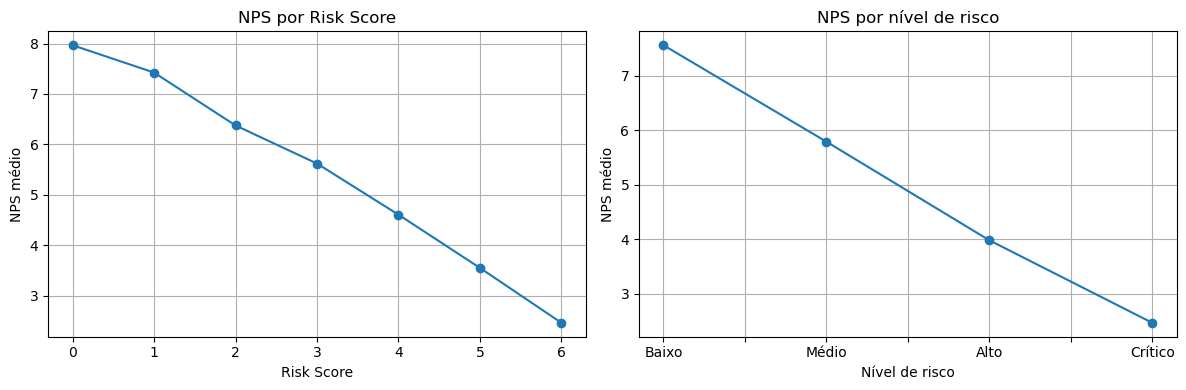

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

# Gráfico 1 - contínuo
df_nps.groupby('risk_score',observed=False)['nps_score'].mean().plot(
    marker='o', ax=axes[0]
)
axes[0].set_title('NPS por Risk Score')
axes[0].set_xlabel('Risk Score')
axes[0].set_ylabel('NPS médio')
axes[0].grid()

# Gráfico 2 - categórico
df_nps.groupby('risk_level',observed=False)['nps_score'].mean().plot(
    marker='o', 
    ax=axes[1]
)
axes[1].set_title('NPS por nível de risco')
axes[1].set_xlabel('Nível de risco')
axes[1].set_ylabel('NPS médio')
axes[1].grid()

plt.tight_layout()
plt.show()

Identificação de relação direta do risk_score com o nps_score, categoricamente e quantitativamente

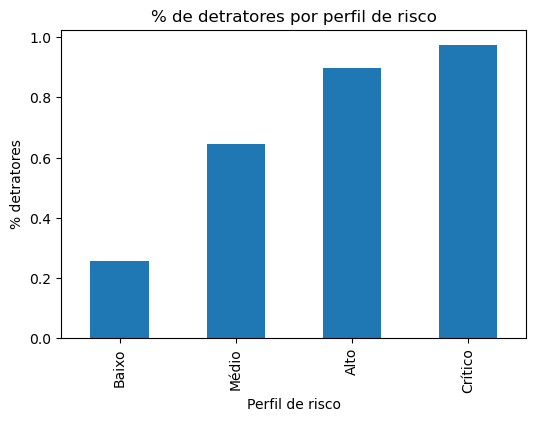

In [60]:
df_nps['is_detrator'] = (df_nps['nps_cat'] == 1)

plt.figure(figsize=(6,4))
df_nps.groupby('risk_level',observed=False)['is_detrator'].mean().plot(kind='bar')
plt.title('% de detratores por perfil de risco')
plt.ylabel('% detratores')
plt.xlabel('Perfil de risco')
plt.show()

é possivel visualizar um acumulo de percentual de detratores, conforme o risco se eleva 

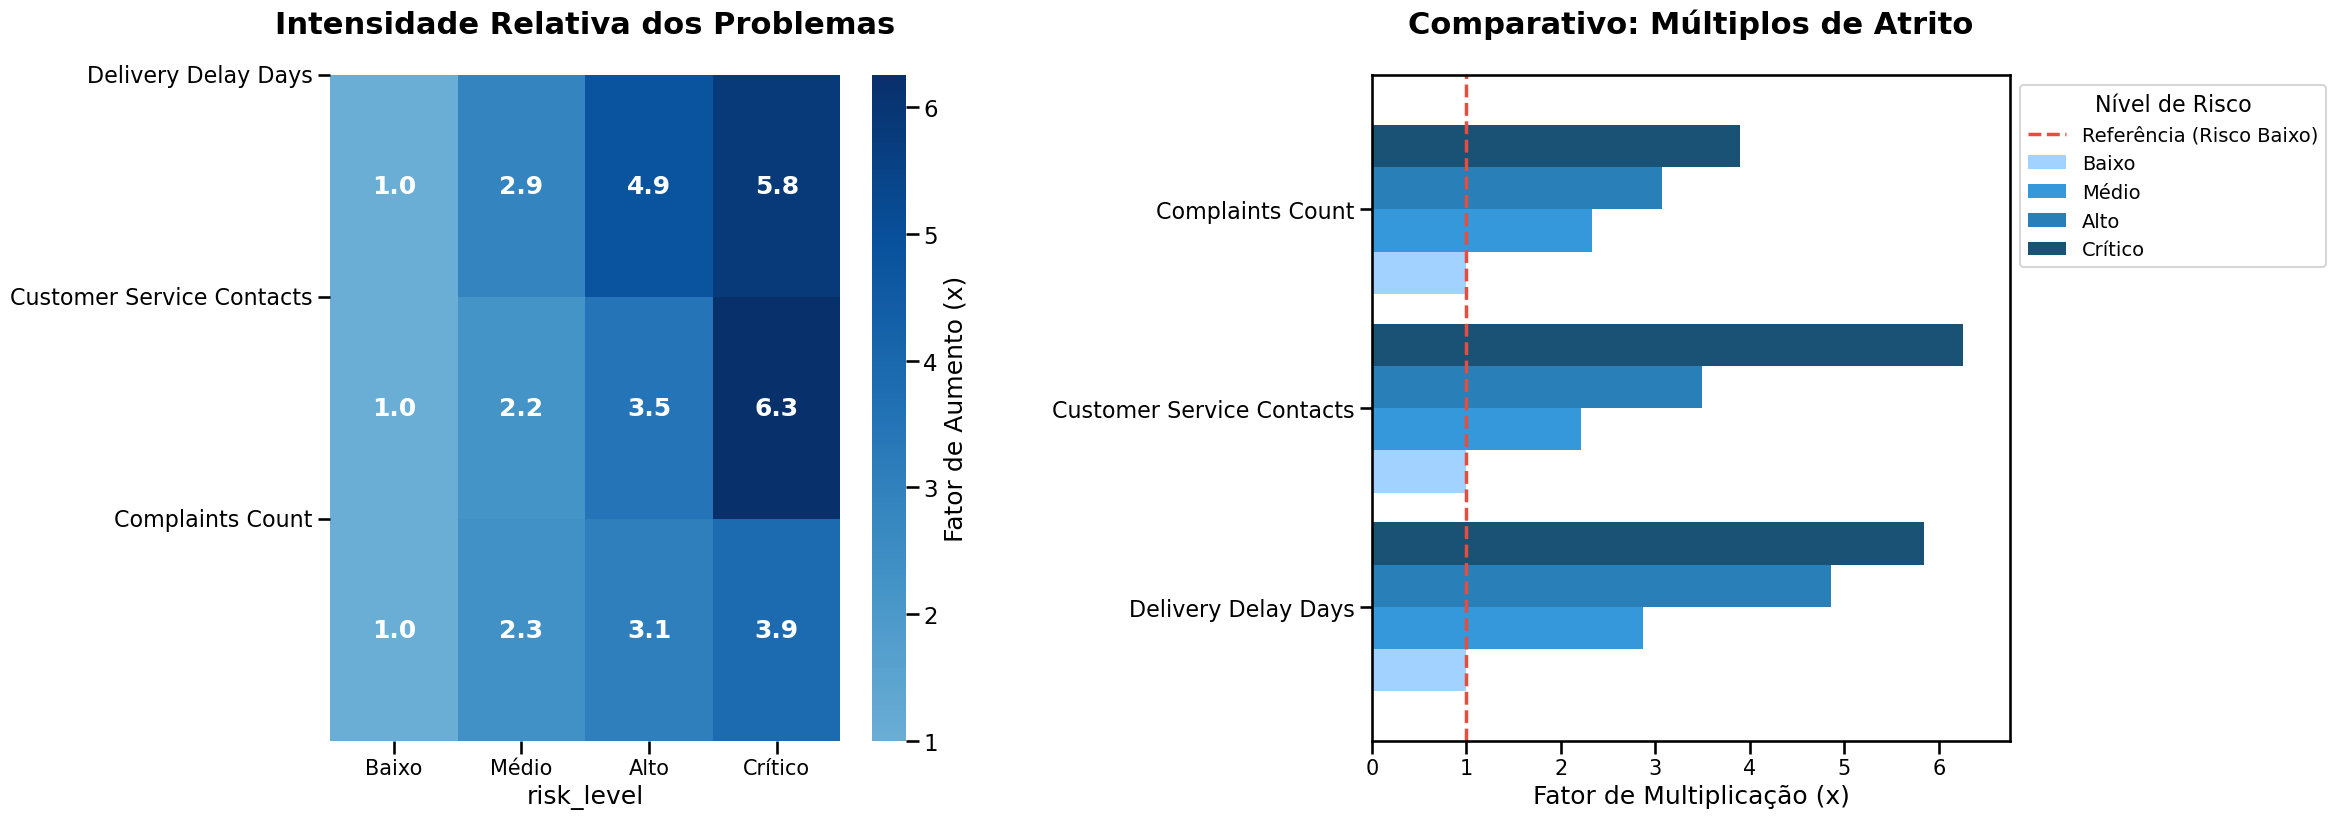

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns
cols = ['delivery_delay_days', 'customer_service_contacts', 'complaints_count']
sns.set_context("talk") 
paleta_cores = ['#A2D2FF', '#3498DB', '#2980B9', '#1A5276']
fig, axes = plt.subplots(1, 2, figsize=(22, 10))

# ------ HEATMAP 
sns.heatmap(perfil_relativo[cols].T, annot=True, fmt=".1f", cmap='Blues', 
            center=1, ax=axes[0], 
            annot_kws={"size": 18, "weight": "bold"}, 
            cbar_kws={'label': 'Fator de Aumento (x)'})

axes[0].set_title('Intensidade Relativa dos Problemas', fontsize=22, pad=30, fontweight='bold')

#------ BARRAS HORIZONTAIS
perfil_relativo[cols].T.plot(kind='barh', ax=axes[1], color=paleta_cores, width=0.85)

axes[1].axvline(1, color='#E74C3C', linestyle='--', linewidth=2.5, label='Referência (Risco Baixo)')
axes[1].set_title('Comparativo: Múltiplos de Atrito', fontsize=22, pad=30, fontweight='bold')
axes[1].set_xlabel('Fator de Multiplicação (x)', fontsize=18)
axes[1].legend(title='Nível de Risco', title_fontsize='16', fontsize='14', bbox_to_anchor=(1, 1))

# #------ AJUSTES DE ESCALA E LEGIBILIDADE
labels_limpos = [c.replace('_', ' ').title() for c in cols]

for ax in axes:
    ax.set_yticks(range(len(labels_limpos)))
    ax.set_yticklabels(labels_limpos, fontsize=16)
    
    ax.tick_params(axis='x', labelsize=15)
    ax.set_ylabel('', fontsize=0)

# Sincronizando os eixos 
axes[1].set_xlim(0, perfil_relativo[cols].max().max() + 0.5)

plt.tight_layout(pad=4.0)
plt.show()

Por fim uma visualização da proporção dos problemas x nivel de risco em uma escala maior 

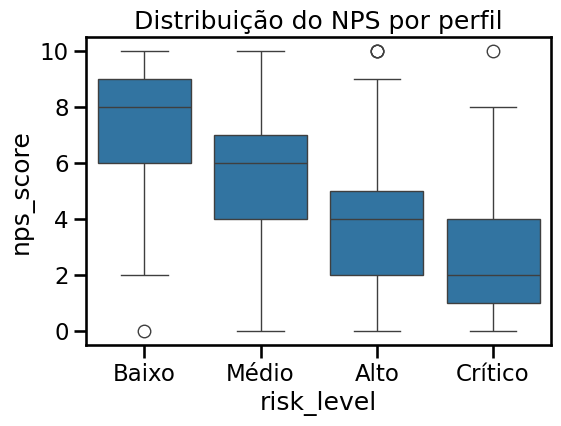

In [62]:
import seaborn as sns

plt.figure(figsize=(6,4))
sns.boxplot(x='risk_level', y='nps_score', data=df_nps)
plt.title('Distribuição do NPS por perfil')
plt.show()

Analise da distribuição de NPS por perfil. <br>
perfil de baixo risco tende a ter um NPS próximo a 8 <br>
médio próximo a 6<br>
Alto próximo a 4 <br>
e critico próximo a 2

# 4. Como forma de preparação para as próximas fases do curso, este desafio propõe uma reflexão prática sobre como a Ciência de Dados pode ser utilizada para antecipar a satisfação do cliente.

Vamos agora normalizar os dados para fazer alguns testes de modelos 

In [114]:
def plot_model_results(model, X_test, y_test, model_name="Modelo"):
    import matplotlib.pyplot as plt
    
    # Previsões
    y_pred = model.predict(X_test)
    
    # Criar figura
    fig, ax = plt.subplots(1, 2, figsize=(15, 6))

    # --- Gráfico 1: Real vs Previsto ---
    ax[0].scatter(y_test, y_pred, alpha=0.5)
    ax[0].plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        'r--', lw=2
    )
    ax[0].set_xlabel('Valores Reais')
    ax[0].set_ylabel('Previsões')
    ax[0].set_title(f'Real vs Previsto ({model_name})')

    # --- Gráfico 2: Resíduos ---
    residuos = y_test - y_pred
    ax[1].hist(residuos, bins=30, edgecolor='black')
    ax[1].axvline(0, linestyle='--')
    ax[1].set_xlabel('Erro (Resíduo)')
    ax[1].set_ylabel('Frequência')
    ax[1].set_title(f'Distribuição dos Erros ({model_name})')

    plt.tight_layout()
    plt.show()
    
def save_model_results(model, X_test, y_test, model_name="Modelo"):
    import matplotlib.pyplot as plt
    
    # Previsões
    y_pred = model.predict(X_test)
    
    # Criar figura
    fig, ax = plt.subplots(1, 2, figsize=(15, 6))

    # --- Gráfico 1: Real vs Previsto ---
    ax[0].scatter(y_test, y_pred, alpha=0.5)
    ax[0].plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        'r--', lw=2
    )
    ax[0].set_xlabel('Valores Reais')
    ax[0].set_ylabel('Previsões')
    ax[0].set_title(f'Real vs Previsto ({model_name})')

    # --- Gráfico 2: Resíduos ---
    residuos = y_test - y_pred
    ax[1].hist(residuos, bins=30, edgecolor='black')
    ax[1].axvline(0, linestyle='--')
    ax[1].set_xlabel('Erro (Resíduo)')
    ax[1].set_ylabel('Frequência')
    ax[1].set_title(f'Distribuição dos Erros ({model_name})')

    plt.tight_layout()
 
    

def avaliar(nome, y_true, y_pred):
    print(f"\n=== {nome} ===")
    print(f"MAE:  {mean_absolute_error(y_true, y_pred):.3f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.3f}")
    print(f"R²:   {r2_score(y_true, y_pred):.3f}")

In [63]:
df_nps.head(2).T

,0,1
customer_age,63,20
customer_tenure_months,14,1
order_id,50001,50002
order_value,139.73,458.95
items_quantity,4,2
discount_value,39.35,9.51
payment_installments,4,10
delivery_time_days,2,6
delivery_delay_days,2,4
freight_value,55.53,28.23


Vamos começar com o one-hot encoder para separarmos as regiões, para isso vamos recuperar as colunas categorias 

In [64]:

from sklearn.preprocessing import OneHotEncoder

#Recriamos o nome da região utilizando nosso map
df_nps['region_name'] = df_nps['customer_region_encoded'].map(region_mapping)

#Configuramos o Encoder e enviamos a coluna de região para ser transformada em One-Hot
cat_encoder = OneHotEncoder()
region_1hot = cat_encoder.fit_transform(df_nps[['region_name']])

# 3. Criamos o DataFrame com os nomes automáticos (que agora serão os nomes das regiões)
df_1hot = pd.DataFrame(
    region_1hot.toarray(), 
    columns=cat_encoder.get_feature_names_out(['region_name']), # Ele usará 'region_Sul', 'region_Norte', etc.
    index=df_nps.index
)

# 4. Concatenamos e removemos a coluna temporária  
df_nps = pd.concat([df_nps, df_1hot], axis=1).drop(['region_name'], axis=1)

Phrofet

In [66]:
features = [
    'complaints_count',
    'delivery_delay_days',
    'customer_service_contacts',
    'resolution_time_days',
    'delivery_time_days',
    'delivery_attempts',
    'order_value',
    'items_quantity',
    'discount_value',
    'payment_installments',
    'freight_value',
    'customer_age',
    'customer_tenure_months',
    'repeat_purchase_30d',
    'region_name_Centro-Oeste',
    'region_name_Nordeste',
    'region_name_Norte',
    'region_name_Sudeste',
    'region_name_Sul',
    'nps_score'  #UTILIZADO APENAS PARA TESTAR OS OUTLIERS, POIS É A VARIÁVEL TARGET
]


#Filtrar outliers
df_treino = df_nps[features].copy()
#df_treino = df_treino.query("nps_score != 0 and nps_score != 10")

y = df_treino['nps_score']
X = df_treino.drop(columns=['nps_score'])

In [67]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,   # 20% teste
    random_state=42  # reprodutibilidade
)

In [68]:
# média do treino
media_treino = y_train.mean()
# cria um vetor do mesmo tamanho do y_test
y_baseline = np.full(len(y_test), media_treino)

In [69]:
print(df_treino.shape)
print(X_train.shape)
print(y_train.shape)

(2500, 20)
(2000, 19)
(2000,)


A utlização do GridSearch serve para verificar os melhores parametros para usarmos em nossos modelos

In [89]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

#iniciamos a base da random forest
rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)


#criamos o grid de hiperparâmetros para testar
param_grid = {
    'max_depth': [5, 10, 15],
    'n_estimators': [100, 200],
}

grid = GridSearchCV(rf_base, param_grid, cv=3, scoring='r2')
grid.fit(X_train, y_train)

#encontramos o melhor modelo
rf = grid.best_estimator_

#Executamos o modelo
y_pred_rf = rf.predict(X_test)



Avanliamos as métricas:

In [90]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

print("=== RANDOM FOREST ===")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_rf):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.3f}")
print(f"R²:   {r2_score(y_test, y_pred_rf):.3f}")

=== RANDOM FOREST ===
MAE:  1.249
RMSE: 1.546
R²:   0.623


In [92]:
#Ver o que o modelo aprendeu 
# 'grid.best_estimator_' é o modelo que realmente aprendeu os dados
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

print("Top 10 variáveis mais importantes:")
print(importances.head(10))

Top 10 variáveis mais importantes:
repeat_purchase_30d          0.368583
delivery_delay_days          0.214764
complaints_count             0.110692
customer_service_contacts    0.055117
resolution_time_days         0.039470
order_value                  0.035847
discount_value               0.031112
freight_value                0.029959
customer_tenure_months       0.028479
customer_age                 0.026142
dtype: float64


In [79]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [80]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

In [ ]:
# MAE: Erro médio em unidades absolutas (fácil de explicar)
mae = mean_absolute_error(y_test, y_pred_gb)
# RMSE: Penaliza erros grandes (muito usado em competições)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))
# R²: Quanto da variação dos dados o modelo explica (0 a 1)
r2 = r2_score(y_test, y_pred_gb)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

MAE: 1.22
RMSE: 1.52
R² Score: 0.63


In [94]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

In [95]:
mae = mean_absolute_error(y_test, y_pred_xgb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2 = r2_score(y_test, y_pred_xgb)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

MAE: 1.24
RMSE: 1.56
R² Score: 0.62


In [ ]:
y_train_pred = lr.predict(X_train)

avaliar("Baseline", y_test, y_baseline)

avaliar("Linear Regression - treino", y_train, y_train_pred)
avaliar("Linear Regression Teste", y_test, y_pred_lr)

avaliar("Random Forest", y_test, y_pred_rf)
avaliar("Gradient Boosting", y_test, y_pred_gb)
avaliar("XGBoost", y_test, y_pred_xgb)


=== Baseline ===
MAE:  2.075
RMSE: 2.517
R²:   -0.000

=== Linear Regression - treino ===
MAE:  1.217
RMSE: 1.525
R²:   0.638

=== Linear Regression Teste ===
MAE:  1.207
RMSE: 1.516
R²:   0.637

=== Random Forest ===
MAE:  1.249
RMSE: 1.546
R²:   0.623

=== Gradient Boosting ===
MAE:  1.225
RMSE: 1.524
R²:   0.634

=== XGBoost ===
MAE:  1.236
RMSE: 1.557
R²:   0.617


Os dados indicam que o melhor modelo que temos é a regressão Linear, com o maior R² o menor MAE e RMSE

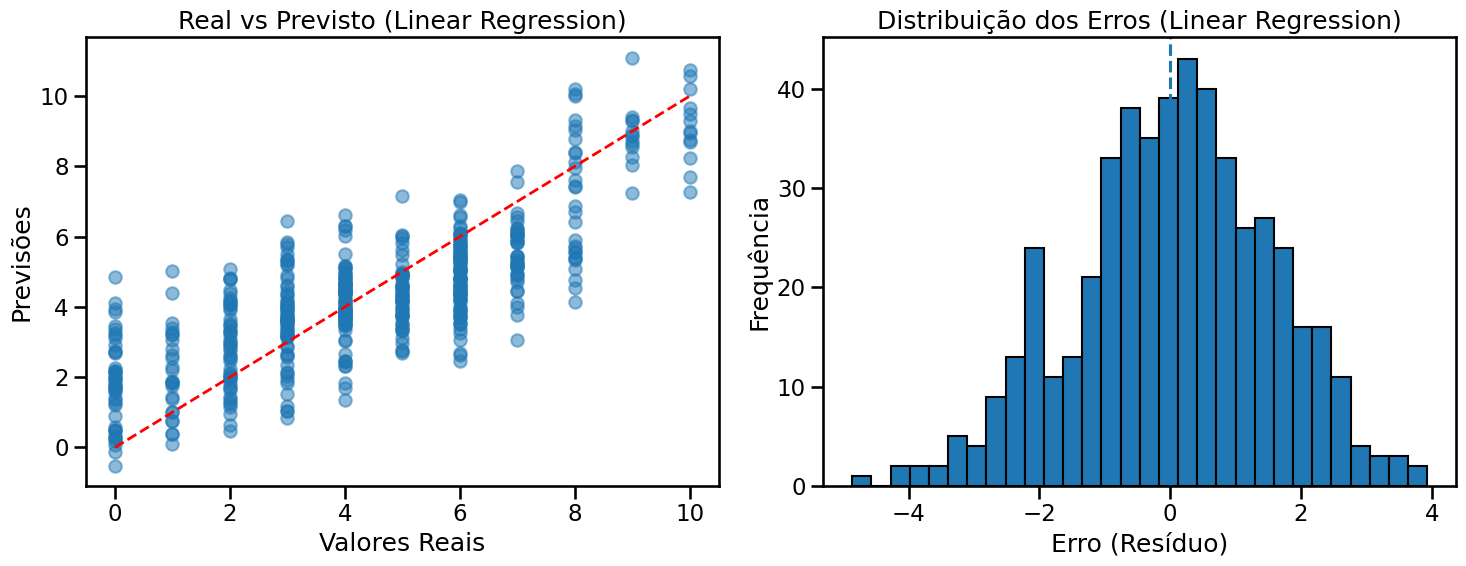

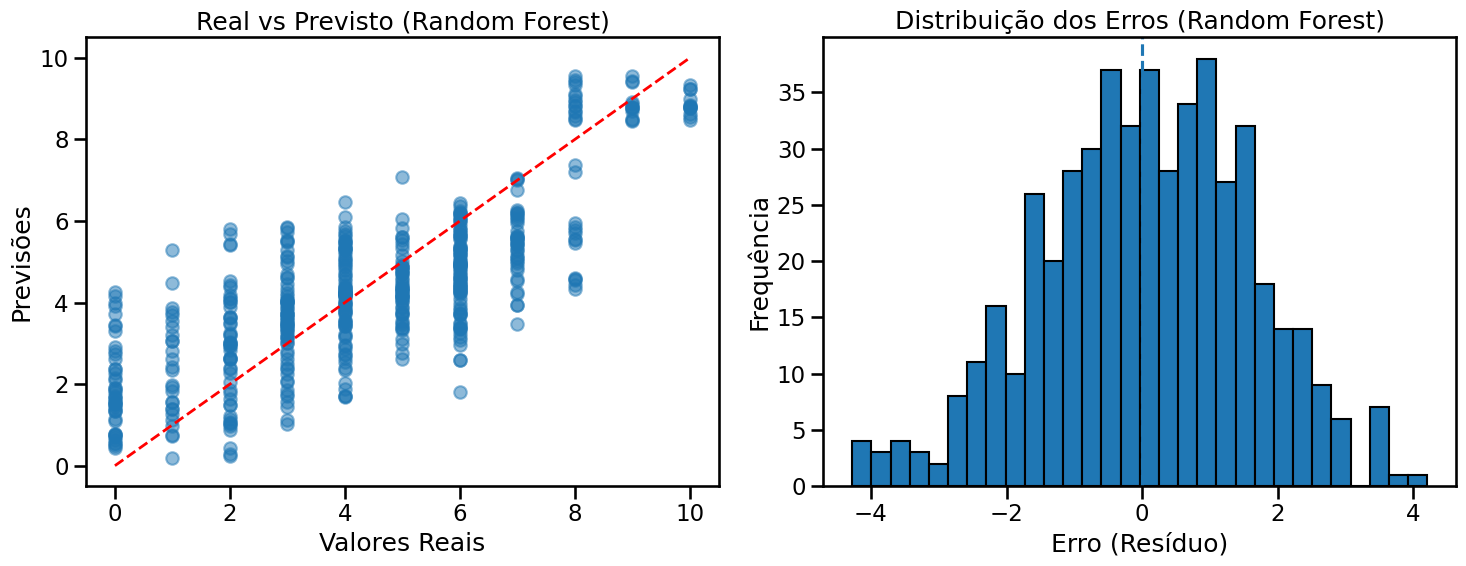

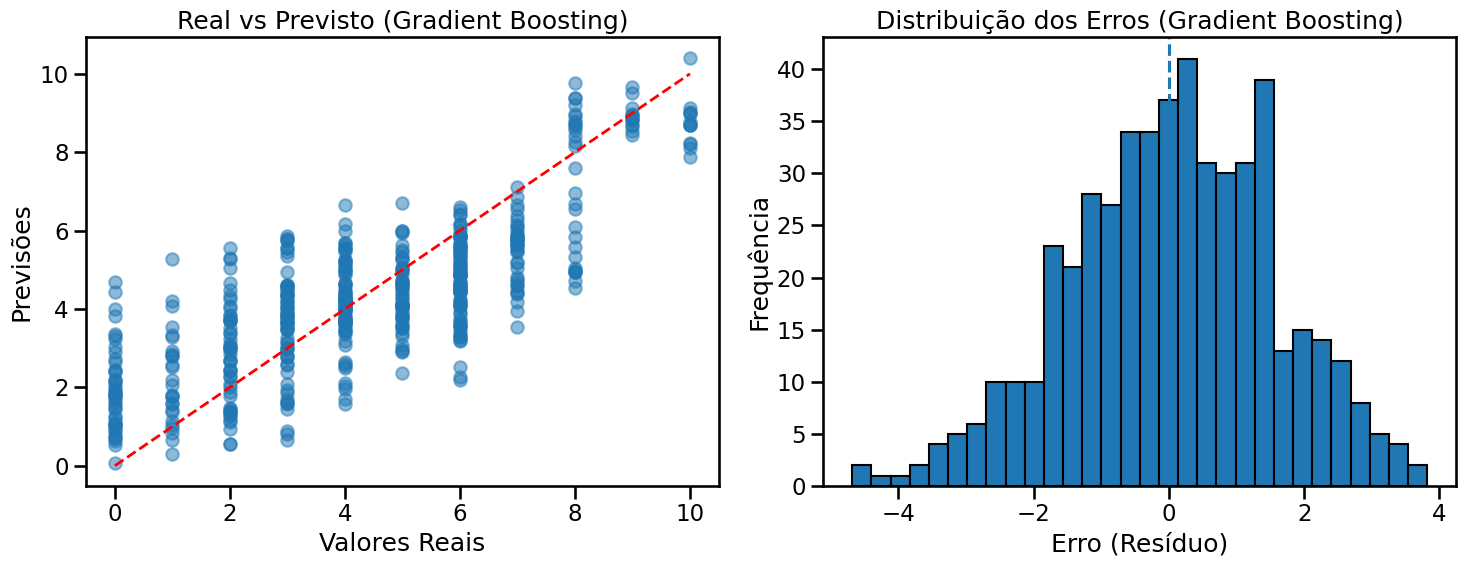

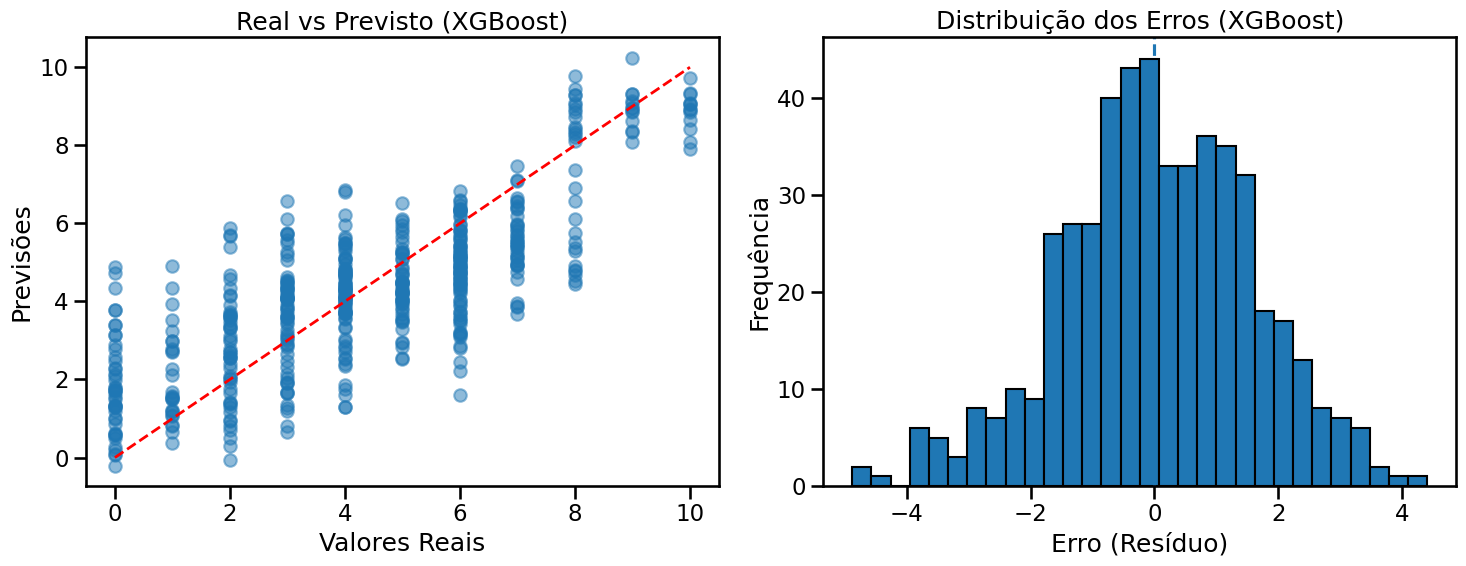

In [ ]:
plot_model_results(lr, X_test, y_test, "Linear Regression")

plot_model_results(rf, X_test, y_test, "Random Forest")
plot_model_results(gb, X_test, y_test, "Gradient Boosting")
plot_model_results(xgb, X_test, y_test, "XGBoost")

In [ ]:
coef = pd.Series(lr.coef_, index=X.columns).sort_values()
print(coef)

delivery_delay_days         -0.808317
customer_service_contacts   -0.349999
complaints_count            -0.265541
region_name_Centro-Oeste    -0.150862
resolution_time_days        -0.115543
freight_value               -0.006557
customer_tenure_months      -0.002194
discount_value              -0.000885
customer_age                -0.000501
region_name_Sudeste          0.000138
order_value                  0.000343
items_quantity               0.008027
delivery_time_days           0.008663
payment_installments         0.015249
region_name_Norte            0.040321
region_name_Sul              0.044049
region_name_Nordeste         0.066354
delivery_attempts            0.088134
repeat_purchase_30d          2.793816
dtype: float64


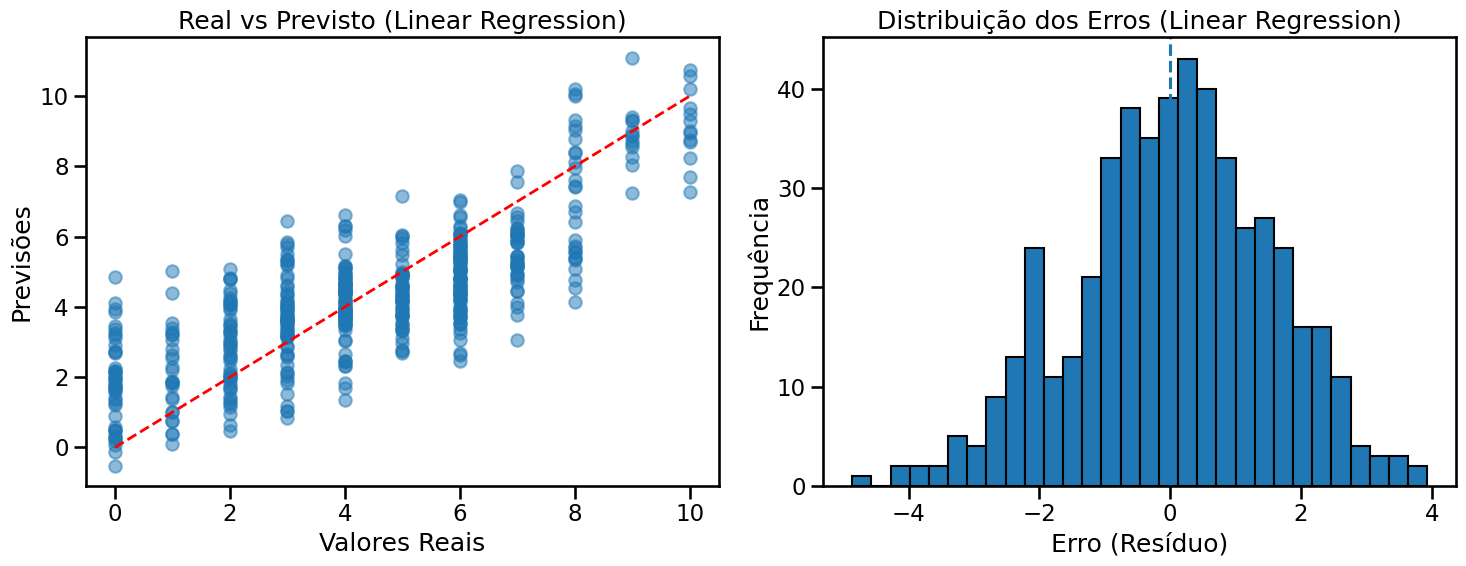

In [104]:
plot_model_results(lr, X_test, y_test, "Linear Regression")

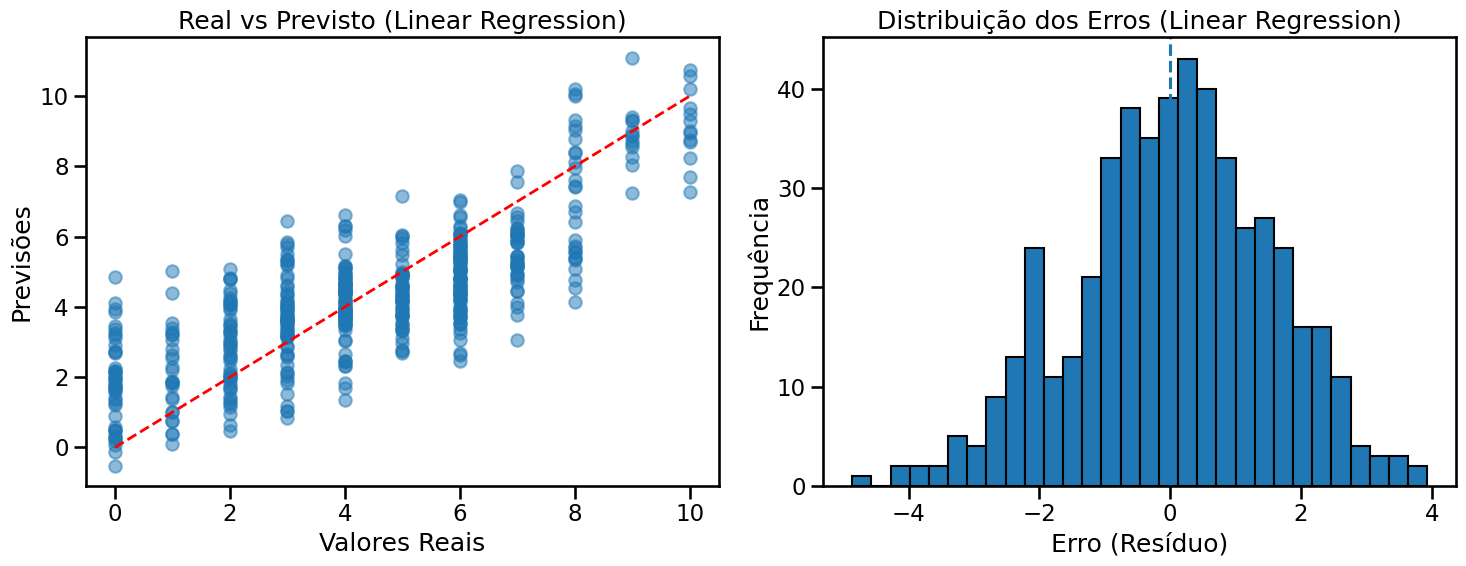

In [115]:
# Cria a pasta se ela não existir
import os
if not os.path.exists('images'):
    os.makedirs('images')

save_model_results(lr, X_test, y_test, "Linear Regression")
fig = plt.gcf()
# Salva dentro da pasta images com uma resolução maior (dpi)
fig.savefig("images/resultado_linear_regression.png", bbox_inches='tight', dpi=300)
plt.show()

In [131]:
cliente = X_test.iloc[0].copy()

print('atraso')
print()
for dias in [0, 1, 2, 3]:
    cliente['delivery_delay_days'] -= dias
    print(f"Redução {dias} dias:", lr.predict(pd.DataFrame([cliente]))[0])

cliente = X_test.iloc[0].copy()
print('='*30)
print()    
print('contatos')
for contatos in [0, 1, 2, 3,5]:
    cliente['customer_service_contacts'] -= contatos
    print(f"Redução {contatos} dias:", lr.predict(pd.DataFrame([cliente]))[0])
    
cliente = X_test.iloc[0].copy()
print('='*30)
print()        
print('Reclamações')
for reclamacao in [0, 1, 2, 3]:
    cliente['complaints_count'] -= reclamacao
    print(f"Redução nº de {reclamacao}:", lr.predict(pd.DataFrame([cliente]))[0])

atraso

Redução 0 dias: 5.120154760243405
Redução 1 dias: 5.9284714373979615
Redução 2 dias: 7.545104791707074
Redução 3 dias: 9.970054823170743

contatos
Redução 0 dias: 5.120154760243405
Redução 1 dias: 5.4701540226942456
Redução 2 dias: 6.170152547595924
Redução 3 dias: 7.220150334948442
Redução 5 dias: 8.970146647202638

Reclamações
Redução nº de 0: 5.120154760243405
Redução nº de 1: 5.38569536116454
Redução nº de 2: 5.9167765630068105
Redução nº de 3: 6.713398365770215


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
    # sem stratify aqui — é regressão, não classificação
)

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Baseline: sempre prever a média do treino
y_baseline = np.full(len(y_test), y_train.mean())

print("=== BASELINE (média) ===")
print(f"MAE:  {mean_absolute_error(y_test, y_baseline):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_baseline)):.3f}")
print(f"R²:   {r2_score(y_test, y_baseline):.3f}")
# R² do baseline = 0 por definição — é o piso mínimo

=== BASELINE (média) ===
MAE:  2.075
RMSE: 2.517
R²:   -0.000


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

In [ ]:
print("=== RANDOM FOREST ===")
print(f"MAE:  {mean_absolute_error(y_test, y_pred):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.3f}")
print(f"R²:   {r2_score(y_test, y_pred):.3f}")

=== RANDOM FOREST ===
MAE:  1.240
RMSE: 1.549
R²:   0.621


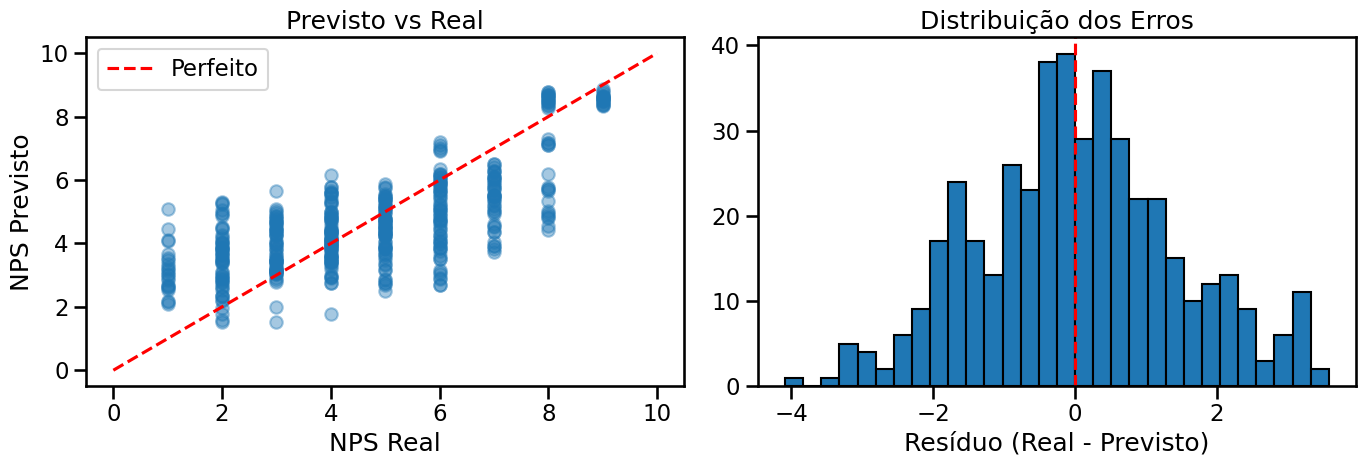

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Previsto vs Real

axes[0].scatter(y_test, y_pred, alpha=0.4)
axes[0].plot([0, 10], [0, 10], 'r--', label='Perfeito')
axes[0].set_xlabel('NPS Real')
axes[0].set_ylabel('NPS Previsto')
axes[0].set_title('Previsto vs Real')
axes[0].legend()

# Distribuição dos resíduos
residuos = y_test - y_pred
axes[1].hist(residuos, bins=30, edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Resíduo (Real - Previsto)')
axes[1].set_title('Distribuição dos Erros')

plt.tight_layout()
plt.show()

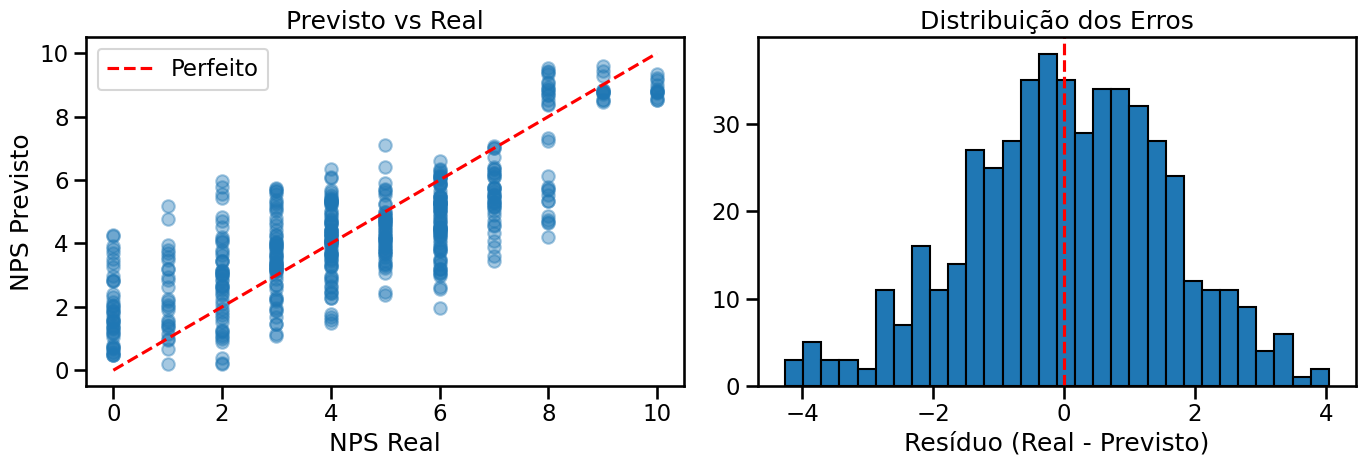

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Previsto vs Real

axes[0].scatter(y_test, y_pred, alpha=0.4)
axes[0].plot([0, 10], [0, 10], 'r--', label='Perfeito')
axes[0].set_xlabel('NPS Real')
axes[0].set_ylabel('NPS Previsto')
axes[0].set_title('Previsto vs Real')
axes[0].legend()

# Distribuição dos resíduos
residuos = y_test - y_pred
axes[1].hist(residuos, bins=30, edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Resíduo (Real - Previsto)')
axes[1].set_title('Distribuição dos Erros')

plt.tight_layout()
plt.show()

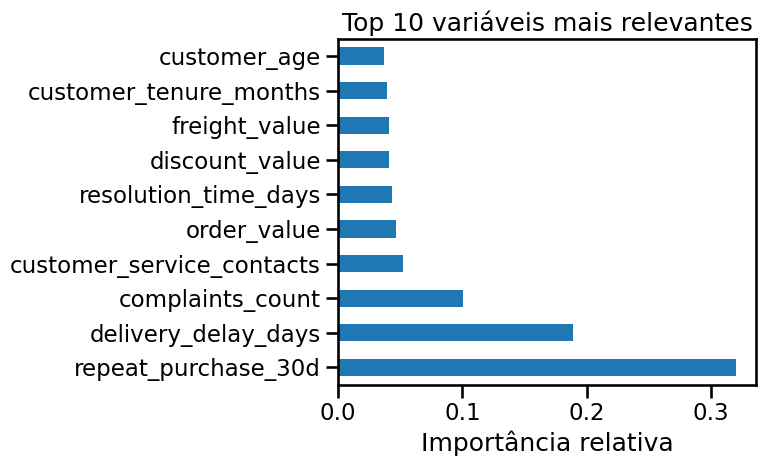

In [ ]:
importancias = pipeline.named_steps['model'].feature_importances_
feat_imp = pd.Series(importancias, index=features).sort_values(ascending=False)

feat_imp.head(10).plot(kind='barh', figsize=(8, 5))
plt.title('Top 10 variáveis mais relevantes')
plt.xlabel('Importância relativa')
plt.tight_layout()
plt.show()

In [ ]:
# O modelo prevê nota → converte para ação
def classificar_risco(nota_prevista):
    if nota_prevista <= 6:
        return 'Risco alto — intervir antes da pesquisa'
    elif nota_prevista <= 8:
        return 'Atenção — monitorar'
    else:
        return 'Promotor esperado'

df_nps['nps_previsto'] = pipeline.predict(X)
df_nps['acao_recomendada'] = df_nps['nps_previsto'].apply(classificar_risco)

In [ ]:
df_nps['acao_recomendada'].value_counts()

acao_recomendada
Risco alto — intervir antes da pesquisa    2000
Atenção — monitorar                         282
Promotor esperado                           218
Name: count, dtype: int64

In [ ]:
model = RandomForestClassifier(
    n_estimators=200,      # número de árvores
    max_depth=10,          # profundidade
    min_samples_split=5,   # mínimo para dividir
    max_features="sqrt",   # variáveis por árvore
    random_state=42
)

NameError: name 'RandomForestClassifier' is not defined